# A Hierarchical Model of Honeybee Waggle-Dances
---

## Details

&ensp;AUTHOR:&emsp;   James Foster &emsp; 2025 03 14

MODIFIED:&emsp; James Foster &emsp; 2026 05 18

DESCRIPTION:&emsp; Fit a hierarchical maximum-likelihood von Mises to honeybee waggle-run angles.
Modified from [beetles.ipynb](https://github.com/jgraving/unwrap/notebooks/)

            
INPUTS:&emsp;   `'colour_dance_reorg.csv'`
            
OUTPUTS:&emsp;  Plots and test statistics

CHANGES: - More specific Python environment for PyMC x unwrap

REFERENCES:
- Sayin S, ... Graving JM, $\textit{et~al}$. (2025)
The behavioral mechanisms governing collective motion in swarming locusts.
$\textit{Science}$ 387,995-1000
DOI:[10.1126/science.adq7832](https://doi.org/10.1126/science.adq7832)

- Graving JM, Sayin S, Costelloe BR, Goldshtein A & Foster JJ. 
Unwrapping circular statistics with Bayesian multilevel models.

---

# First set up the required packages
Don't forget to make sure the the kernel is running in a `conda` environment.
To fit models using `g++` (recommended for speed) make sure `m2w64-toolchain` is installed on Windows.

In [9]:
import sys

#20260518
# requirements = """
# numpy==1.26.4
# pandas==2.2.2
# scipy==1.16.2
# arviz==0.22.0
# bambi==0.14.0
# pymc==5.16.2
# pytensor==2.25.5
# xarray==2025.10.1
# matplotlib==3.8.4
# formulae==0.5.4
# numba==0.59.1
# git+https://github.com/jgraving/unwrap
# """

#20260519
requirements = """
numpy==1.26.4
pandas==2.2.2
scipy==1.13.1
arviz==0.19.0
bambi==0.14.0
pymc==5.16.2
matplotlib==3.8.4
formulae==0.5.4
numba==0.59.1
git+https://github.com/jgraving/unwrap.git
"""

# Write it to a file
with open("bambi_unwrap_requirements.txt", "w") as f:
    f.write(requirements.strip() + "\n")

# Install everything from the file
!{sys.executable} -m pip install -r bambi_unwrap_requirements.txt --no-cache

%set_env PYTENSOR_FLAGS=blas__ldflags='-llapack -lblas -lcblas'

Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/jgraving/unwrap.git to c:\users\james foster\appdata\local\temp\pip-req-build-p9bvivzc
  Resolved https://github.com/jgraving/unwrap.git to commit 3e701175b665a12f4a0dcda6643aef9ea4b7aecf
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
env: PYTENSOR_FLAGS=blas__ldflags='-llapack -lblas -lcblas'


  Running command git clone --filter=blob:none --quiet https://github.com/jgraving/unwrap.git 'C:\Users\James Foster\AppData\Local\Temp\pip-req-build-p9bvivzc'


Report packages installed in enviroment.

In [10]:
!{sys.executable} -m pip list

Package                           Version
--------------------------------- ------------------
aiobotocore                       2.12.3
aiohappyeyeballs                  2.4.0
aiohttp                           3.10.5
aioitertools                      0.7.1
aiosignal                         1.2.0
alabaster                         0.7.16
altair                            5.0.1
anaconda-anon-usage               0.4.4
anaconda-catalogs                 0.2.0
anaconda-client                   1.12.3
anaconda-cloud-auth               0.5.1
anaconda-navigator                2.6.3
anaconda-project                  0.11.1
annotated-types                   0.6.0
anyio                             4.2.0
appdirs                           1.4.4
archspec                          0.2.3
argon2-cffi                       21.3.0
argon2-cffi-bindings              21.2.0
arro3-core                        0.6.5
arrow                             1.2.3
arviz                             0.19.0
astroid          

# Set up custom functions
Create a function for plotting circular model output.

In [11]:
import matplotlib.pyplot as plt
import arviz as az

def plot_circular_trace(idata, 
                        vars, 
                        cvars, 
                        cvar_units='degrees', 
                        save_trans=False):
    """
    Transforms circular posterior variables from radians to degrees (inverted 
    for clockwise plotting) and plots the ArviZ trace.
    
    Parameters:
    -----------
    idata : arviz.InferenceData
        The ArviZ InferenceData object containing the posterior samples.
    vars : list of str
        The full list of variable names to plot in the trace.
    cvars : list of str
        The subset of variable names that are circular and need transformation.
    cvar_units : str, optional
        Units for the circular variables (e.g., 'degrees' or 'radians'). Default is 'degrees'.
    save_trans : bool, optional
        Whether to return the transformed InferenceData object. Default is True.
        
    Returns:
    --------
    idata_trans : arviz.InferenceData or None
        A copy of the InferenceData object with transformed circular variables if save_trans=True, 
        otherwise None.
    """
    # Transform the circular data for interpretability
    idata_trans = idata.copy()  # set up a variable for transformed data
    
    if cvar_units == 'degrees':
        for cvar in cvars:
            # Convert each to degrees and invert to plot clockwise
            idata_trans.posterior[cvar] = -180 * idata_trans.posterior[cvar] / np.pi 

    # Generate the trace plot
    az.plot_trace(
        idata_trans,
        var_names=vars,
        circ_var_names=cvars,
        circ_var_units=cvar_units
    ) 
    
    plt.tight_layout()
    plt.show()
    
    if save_trans:
        return idata_trans
    
    return None

# Prepare the data
## Import and format the data
Load the preprocessed data from CSV and convert to radians. Relabel the two conditions in each factor to binary.

In [12]:

import pandas as pd
import numpy as np
from unwrap.link.numpy import shifted_modulo

# Load the file
file_path = '1Data/colour_dance_reorg.csv'#JJF windows is having trouble finding this file
df = pd.read_csv(file_path, sep=',')

# Create a binary indicator for the light intensity (1 for 'low', 0 for 'high')
df['B'] = df['brightn'].apply(lambda x: 1 if 'l' in x else 0)
# Create a binary indicator for the light colour (1 for 'UV', 0 for 'green')
df['C'] = df['colour'].apply(lambda x: 1 if 'u' in x else 0)
# Rename sun azimuth to use capitalised label
df['SunAz'] = df['sun_az_rad']
# Rename run to use capitalised label
df['Run'] = df['run']

# Convert the dance angle column to the correct format (already radians?)
df['angle'] = pd.to_numeric(df['angle'], errors='coerce')  # Convert non-numeric values (e.g., 'NA') to NaN

# Normalise all angles to be between -pi and pi (should be already)
df['angle'] = df['angle'].apply(lambda x: shifted_modulo(x) if pd.notnull(x) else x)
df['sun_az_rad'] = df['sun_az_rad'].apply(lambda x: shifted_modulo(x) if pd.notnull(x) else x)

# Keep only the relevant columns and drop rows with missing values
# df = df[['angle','ID', 'B', 'C', 'Run','SunAz']].dropna().copy()
df = df[['angle','ID', 'B', 'C', 'Run','SunAz']].copy()#we don't need to drop NA as we're not using SunAz
df.reset_index(drop=True, inplace=True)

# Rename columns: change 'ID' to 'Individual'
df = df.rename(columns={'ID': 'Individual'})
df['Individual'] = df['Individual'].astype('category')

# Simplify to codes
df['Individual'] = df['Individual'].cat.codes + 1
#save to align with raw data in R
df.to_feather('1Data/colour_dance_reorg.feather')

df.head()

,angle,Individual,B,C,Run,SunAz
0,1.570796,3,1,1,1,-2.647205
1,-0.087266,3,1,1,2,-2.647205
2,-0.349066,3,1,1,3,-2.647205
3,0.698132,3,1,1,4,-2.647205
4,-0.349066,3,1,1,5,-2.647205


## Inspect the data
Use Jake's plots to show the repeated angles across individuals.
Maybe limit this to just 10 individuals for now.

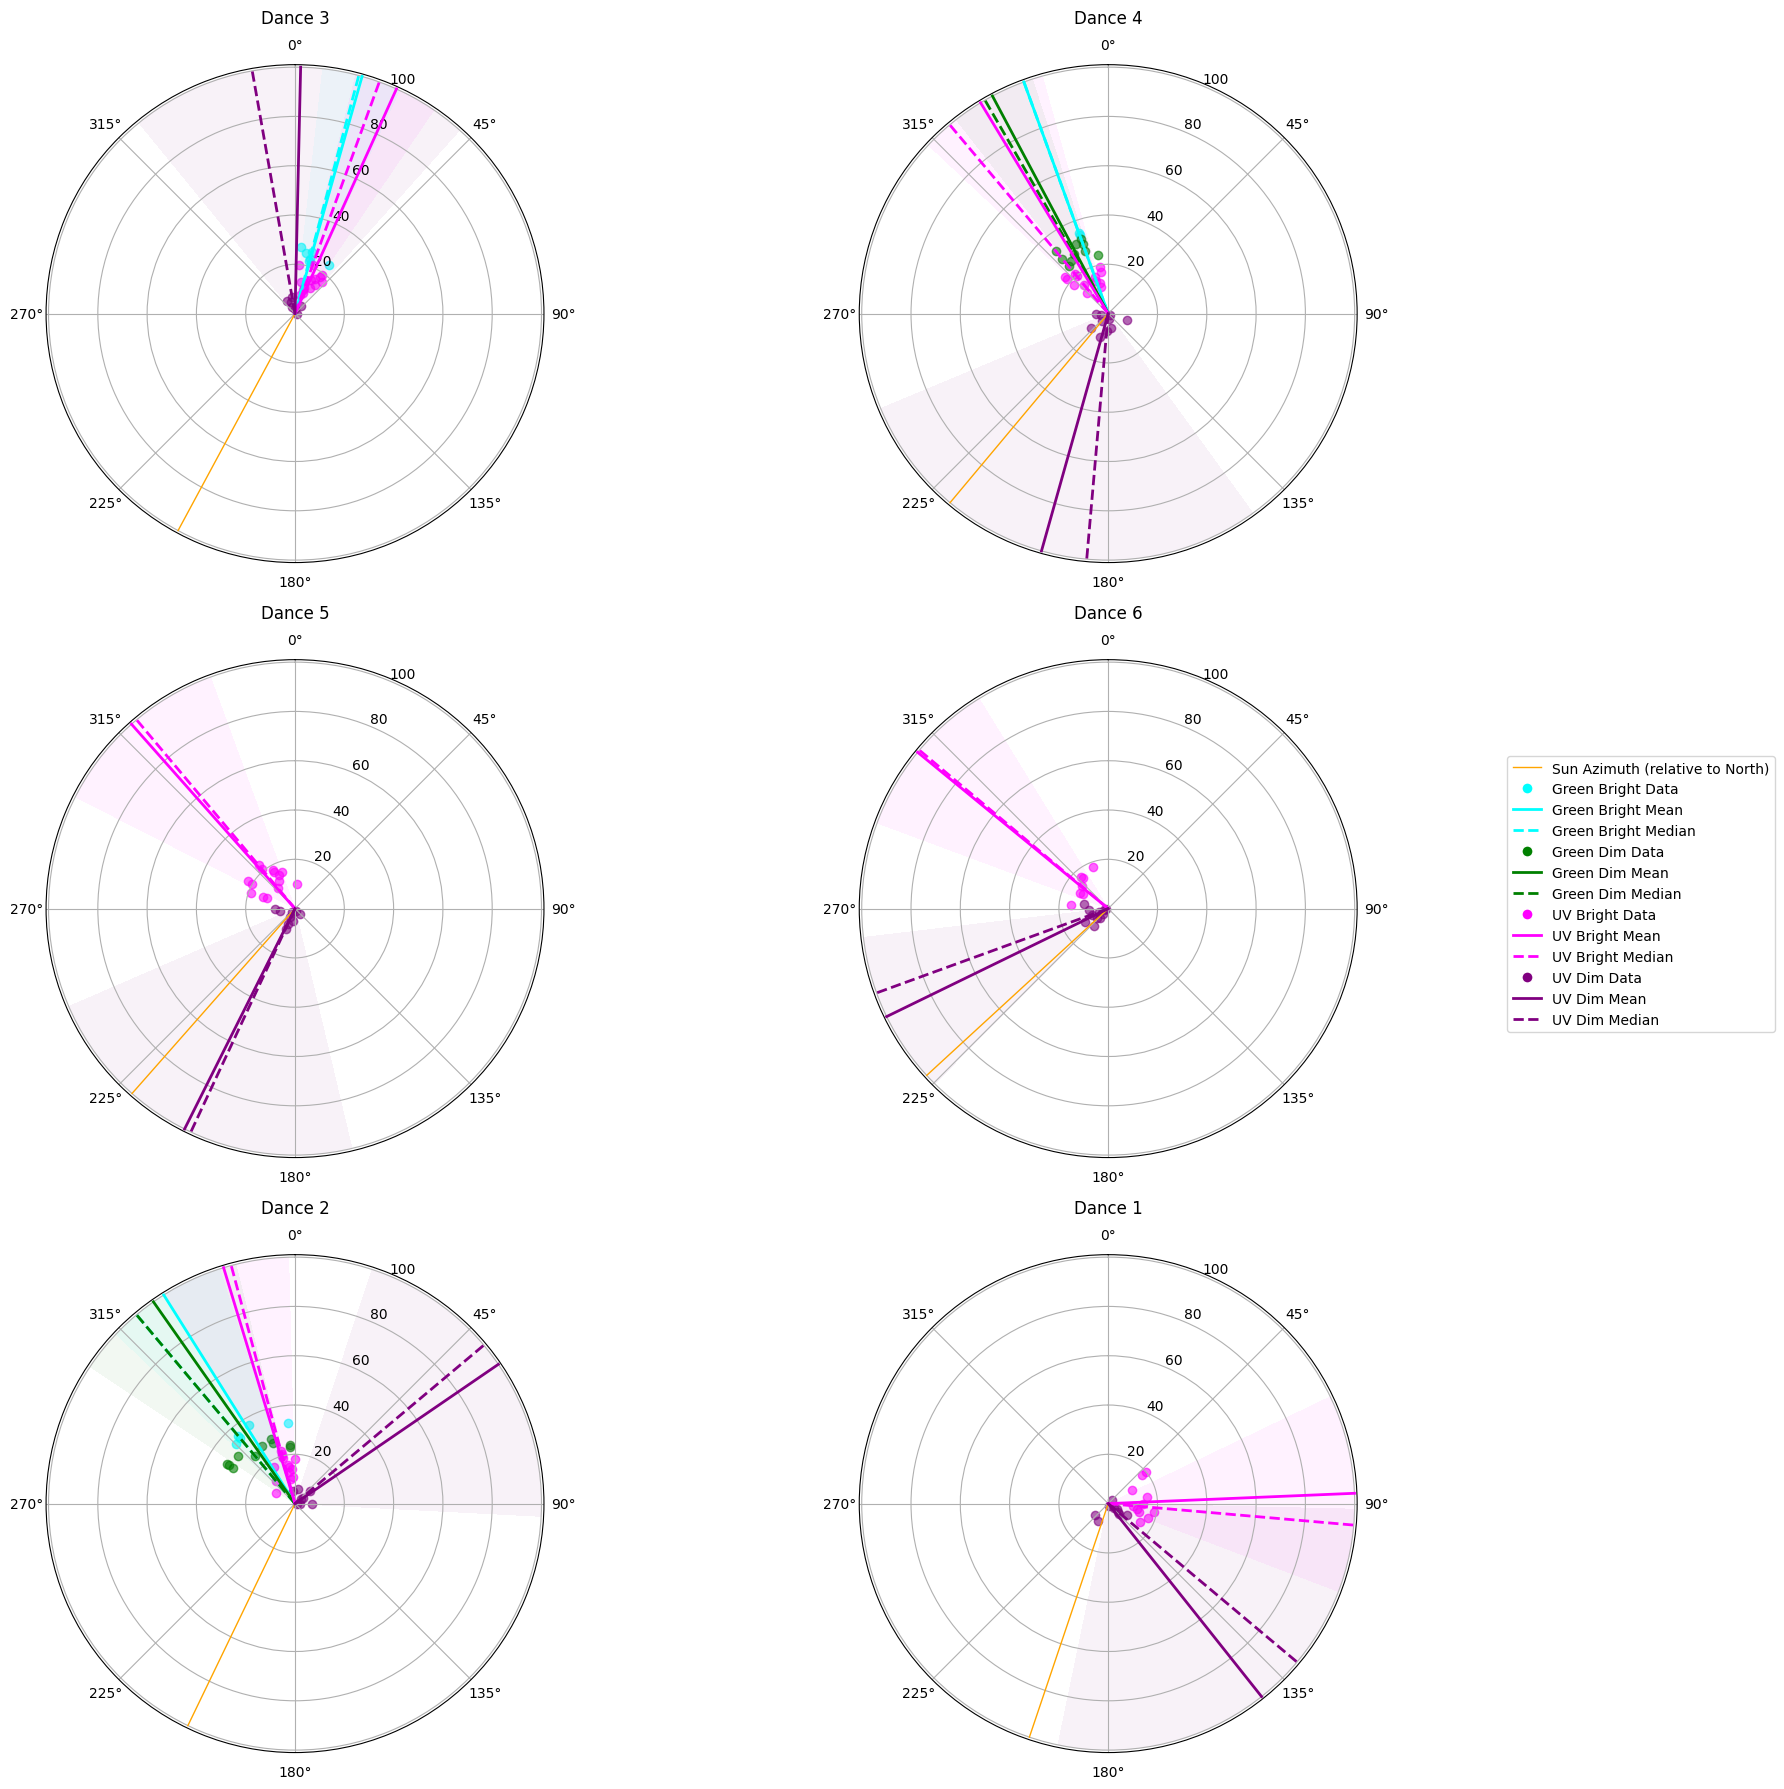

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd
from matplotlib.lines import Line2D

# Helper function to compute the circular median.
def circ_median(angles):
    angles = np.sort(angles)
    diffs = np.abs(np.angle(np.exp(1j * (angles[:, None] - angles[None, :]))))
    sum_diffs = np.sum(diffs, axis=1)
    return angles[np.argmin(sum_diffs)]

# Helper function to scatter-plot data for one condition.
def plot_scatter(ax, data, angle_col, radial_col, color, label):
    if not data.empty:
        ax.scatter(data[angle_col], data[radial_col],
                   color=color, alpha=0.6, label=label)

# Helper function to compute and plot summary statistics.
# It plots a solid vertical line at the circular mean and a dashed vertical line at the circular median,
# both in the specified color. It also fills the region ± the circular standard deviation.
def plot_summary_stats(ax, angles, radial_max, color):
    # Compute circular mean, median, and standard deviation.
    mean_val = circmean(angles, high=np.pi, low=-np.pi)
    median_val = circ_median(angles)
    std_val = circstd(angles, high=np.pi, low=-np.pi, normalize=True)
    
    # Plot mean (solid) and median (dashed).
    ax.plot([mean_val, mean_val], [0, radial_max], color=color, linewidth=2)
    ax.plot([median_val, median_val], [0, radial_max], color=color, linewidth=2, linestyle='--')
    
    # Fill the region between mean minus std and mean plus std.
    theta_vals = np.linspace(mean_val - std_val, mean_val + std_val, 100)
    r_vals = np.linspace(0, radial_max, 100)
    Theta, R = np.meshgrid(theta_vals, r_vals)
    ax.contourf(Theta, R, np.ones_like(Theta), alpha=0.05, colors=[color]) # was alpha = 0.2, but covers too much data
    
    return mean_val, median_val, std_val

# Get unique individual IDs.
unique_individuals = df['Individual'].unique()
unique_individuals = unique_individuals[range(0,6)] # for now just the 1st 6 

# Create a grid of polar subplots.
n_plots = len(unique_individuals)
n_rows, n_cols = ( np.intc(n_plots/2) , 2  ) # Adjust grid dimensions as needed.
fig, axes = plt.subplots(n_rows, n_cols, subplot_kw={'projection': 'polar'}, figsize=(18, np.intc(n_plots*3)))
axes = axes.flatten()

# radial_max = 10*4  # Maximum radial value
radial_max = np.max(df['Run'])  # Maximum radial value (maximum runs)

# Plot for each individual.
for idx, individual in enumerate(unique_individuals):
    ax = axes[idx]
    # Set axes to geographic format (clockwise, 0° at the top)
    ax.set_theta_direction(-1)#reverse to clockwise
    ax.set_theta_zero_location('N')#place 0° at the top
    individual_data = df[df['Individual'] == individual]
    
    # Separate Light bright and Light dim data (drop NaNs in angle).
    data_on = individual_data[individual_data['B'] == 0].dropna(subset=['angle'])
    data_off = individual_data[individual_data['B'] == 1].dropna(subset=['angle'])
    # Separate bright data.
    data_gh = data_on[data_on['C'] == 0]
    data_uh = data_on[data_on['C'] == 1]
    # Separate dim data.
    data_gl = data_off[data_off['C'] == 0]
    data_ul = data_off[data_off['C'] == 1]
    
    # Scatter-plot data.
    plot_scatter(ax, data_gh, 'angle', 'Run', 'cyan', 'Green Bright')
    plot_scatter(ax, data_gl, 'angle', 'Run', 'green', 'Green Dim')
    plot_scatter(ax, data_uh, 'angle', 'Run', 'magenta', 'UV Bright')
    plot_scatter(ax, data_ul, 'angle', 'Run', 'purple', 'UV Dim')
    
    #Plot the sun's azimuth for reference
    ax.plot(individual_data['SunAz'].values[range(0,2)], [0, radial_max], color='orange', linewidth=1)
    # Plot summary statistics for each condition.
    if not data_gh.empty:
        plot_summary_stats(ax, data_gh['angle'].values, radial_max, 'cyan')
    if not data_gl.empty:
        plot_summary_stats(ax, data_gl['angle'].values, radial_max, 'green')
    if not data_uh.empty:
        plot_summary_stats(ax, data_uh['angle'].values, radial_max, 'magenta')
    if not data_ul.empty:
        plot_summary_stats(ax, data_ul['angle'].values, radial_max, 'purple')
    
    ax.set_title(f'Dance {individual}', pad=30)
    ax.set_ylim(0, radial_max + 1)
    # Remove individual legends from each subplot.
    ax.legend().set_visible(False)

# Create a shared custom legend.
legend_handles = [
    # For sun azimuth (orange)
    Line2D([0], [0], color = 'orange', lw = 1, label = 'Sun Azimuth (relative to North)'),
    # For green bright (cyan)
    Line2D([0], [0], marker='o', color='w', markerfacecolor='cyan', markersize=8, label='Green Bright Data'),
    Line2D([0], [0], color='cyan', lw=2, label='Green Bright Mean'),
    Line2D([0], [0], color='cyan', lw=2, linestyle='--', label='Green Bright Median'),
    # For green dim (green)
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='Green Dim Data'),
    Line2D([0], [0], color='green', lw=2, label='Green Dim Mean'),
    Line2D([0], [0], color='green', lw=2, linestyle='--', label='Green Dim Median'),
    # For UV bright (magenta)
    Line2D([0], [0], marker='o', color='w', markerfacecolor='magenta', markersize=8, label='UV Bright Data'),
    Line2D([0], [0], color='magenta', lw=2, label='UV Bright Mean'),
    Line2D([0], [0], color='magenta', lw=2, linestyle='--', label='UV Bright Median'),
    # For UV dim (purple)
    Line2D([0], [0], marker='o', color='w', markerfacecolor='purple', markersize=8, label='UV Dim Data'),
    Line2D([0], [0], color='purple', lw=2, label='UV Dim Mean'),
    Line2D([0], [0], color='purple', lw=2, linestyle='--', label='UV Dim Median'),
]

# Add one shared legend to the right of the figure.
fig.legend(handles=legend_handles, loc='center right', bbox_to_anchor=(1.10, 0.5), fontsize='medium')

plt.tight_layout()
plt.show()

# Fit a circular model with individual effects but no interactions
To begin with fit a model with only the effects of different individuals, light intensities and LED colours.

$\mu \sim$ B + C + (1 + B + C + B:C |Individual)

$\kappa \sim$ B + C + (1 + B + C + B:C |Individual)


In [14]:
import numpy as np
import pandas as pd
import bambi as bmb
import arviz as az
import matplotlib.pyplot as plt

from unwrap.link.bambi import LINKS
from unwrap.link.numpy import inverse_softplus
from unwrap.prior import CircularUniformPrior
from pymc import VonMises
from scipy.stats import vonmises, circstd

# Define the model formula with updated, capitalized variable names.
formula = bmb.Formula(
    "angle ~ B + C + B:C + (1 + B + C + B:C |Individual)",
    "kappa ~ B + C + B:C + (1 + B + C + B:C |Individual)",
)


# Specify priors for the model with capitalized keys and updated variable names.
priors = {
    # Fixed effects for μ:
    "Intercept": CircularUniformPrior(), # Test
    "B": bmb.Prior("Normal", mu=0, sigma=np.pi/12), # Works
    "C": bmb.Prior("Normal", mu=0, sigma=np.pi/12), # Works
    "B:C": bmb.Prior("Normal", mu= 0, sigma=np.pi/6), # Test 
    # Individual-level effects for μ: #bias to high kappa appears to cause divergent transitions here; large sigma slows estimation; mu=log(30), sigma=0.1 appears to be a good compromise.
    "1|Individual": bmb.Prior(
        "VonMises", mu=0, kappa=bmb.Prior("LogNormal", mu=np.log(30), sigma=0.60) # Informative prior, individuals close to pop mean circsd ~10° # do not change!
    ),
    "B|Individual": bmb.Prior(
        "VonMises", mu=0, kappa=bmb.Prior("LogNormal", mu=np.log(30), sigma=0.1) # Rhat too high, could be lower mean?
    ),
    "C|Individual": bmb.Prior(
        "VonMises", mu=0, kappa=bmb.Prior("LogNormal", mu=np.log(30), sigma=0.1) # Informative prior but long tails, individuals respond to colour in the same way # try tightening
    ),
    "B:C|Individual": bmb.Prior(
        "VonMises", mu=0, kappa=bmb.Prior("LogNormal", mu=np.log(10), sigma=0.1) # Informative prior but long tails, individuals respond to colour in the same way # try tightening
    ),#Test
    # Priors for the κ-model (inside the "kappa" dictionary):
    "kappa": {
        # Fixed effects for κ:
        "Intercept": bmb.Prior("Normal", mu=inverse_softplus(3), sigma=0.5), # Works
        "B": bmb.Prior("Normal", mu=0, sigma=0.3), # Works
        "C": bmb.Prior("Normal", mu=0, sigma=0.3), # Works
        "B:C": bmb.Prior("Normal", mu=0, sigma=1.0), # Works
        # Individual-level effects for κ:
        "1|Individual": bmb.Prior(
            "Normal", mu=0, sigma=bmb.Prior("HalfStudentT", nu=3, sigma=0.5)
            ), #Works
        "B|Individual": bmb.Prior(
            "Normal", mu=0, sigma=bmb.Prior("HalfStudentT", nu=3, sigma=0.3) #Test
        ),
        "C|Individual": bmb.Prior(
            "Normal", mu=0, sigma=bmb.Prior("HalfStudentT", nu=3, sigma=0.3) #Test
        ),
        "B:C|Individual": bmb.Prior(
            "Normal", mu=0, sigma=bmb.Prior("HalfStudentT", nu=3, sigma=0.5) #Test
        ),
        }
}

# Build the model using the updated formula and priors.
model = bmb.Model(
    formula,
    df,
    family="vonmises",
    priors=priors,
    link={"mu": LINKS["shifted_modulo"], "kappa": LINKS["softplus"]},
    center_predictors=False,
    dropna=True,
)

print(model)

# Fit the model.
idata = model.fit(draws= 2000,#longer run for mu convergence
                  tune = 1000,
                  progressbar="split+stats",
                  idata_kwargs={"log_likelihood": True},
                  target_accept= 0.98  # Needs sampling with small steps or generates some divergences 0.95 works
        ) # be prepared for this to take 90 minutes with high adapt delta

# Save model.
az.to_netcdf(idata, "GUV_unwrap_model.nc")

       Formula: angle ~ B + C + B:C + (1 + B + C + B:C |Individual)
                kappa ~ B + C + B:C + (1 + B + C + B:C |Individual)
        Family: vonmises
          Link: mu = shifted_modulo
                kappa = softplus
  Observations: 6231
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ CircularUniform()
            B ~ Normal(mu: 0.0, sigma: 0.2618)
            C ~ Normal(mu: 0.0, sigma: 0.2618)
            B:C ~ Normal(mu: 0.0, sigma: 0.5236)
        
        Group-level effects
            1|Individual ~ VonMises(mu: 0.0, kappa: LogNormal(mu: 3.4012, sigma: 0.6))
            B|Individual ~ VonMises(mu: 0.0, kappa: LogNormal(mu: 3.4012, sigma: 0.1))
            C|Individual ~ VonMises(mu: 0.0, kappa: LogNormal(mu: 3.4012, sigma: 0.1))
            B:C|Individual ~ VonMises(mu: 0.0, kappa: LogNormal(mu: 2.3026, sigma: 0.1))
    target = kappa
        Common-level effects
            kappa_Intercept ~ Normal(mu: 2.9489, sigma: 0.5)
      

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, B, C, B:C, 1|Individual_kappa, 1|Individual, B|Individual_kappa, B|Individual, C|Individual_kappa, C|Individual, B:C|Individual_kappa, B:C|Individual, kappa_Intercept, kappa_B, kappa_C, kappa_B:C, kappa_1|Individual_sigma, kappa_1|Individual_offset, kappa_B|Individual_sigma, kappa_B|Individual_offset, kappa_C|Individual_sigma, kappa_C|Individual_offset, kappa_B:C|Individual_sigma, kappa_B:C|Individual_offset]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 12504 seconds.


'GUV_unwrap_model.nc'

## Check convergence heuristics



In [22]:
#check convergence heuristics
az.summary(
    idata, 
    var_names=["Intercept", #slightly right shifted, should converge to around 0.26
               "B", 
                "C",
                "B:C",
                "kappa_Intercept",
               "kappa_B",
                "kappa_C",
                "kappa_B:C",
                ],
    circ_var_names=["Intercept",
                    "B",
                    "C",
                    "B:C",
                    ]
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,0.195,0.086,0.035,0.359,0.002,0.003,495.0,757.0,1.01
B,-0.434,0.066,-0.552,-0.307,0.001,0.001,6911.0,6546.0,1.00
C,0.071,0.037,-0.002,0.136,0.000,0.000,4632.0,5462.0,1.00
B:C,-1.201,0.097,-1.391,-1.025,0.001,0.001,2617.0,4807.0,1.00
kappa_Intercept,5.454,0.272,4.934,5.943,0.003,0.002,6112.0,6660.0,1.00
kappa_B,-1.807,0.286,-2.331,-1.261,0.004,0.003,4887.0,5958.0,1.00
kappa_C,1.882,0.254,1.399,2.354,0.004,0.003,3713.0,5621.0,1.00
kappa_B:C,-3.948,0.432,-4.757,-3.126,0.009,0.006,2509.0,4736.0,1.00


In [23]:
#check convergence heuristics on random effects
az.summary(
    idata, 
    var_names=[
        "1|Individual_kappa",
        "B|Individual_kappa",
        "C|Individual_kappa",
        "B:C|Individual_kappa",
        "kappa_1|Individual_sigma",
        "kappa_B|Individual_sigma",
        "kappa_C|Individual_sigma",
        "kappa_B:C|Individual_sigma",
                ],
    # filter_vars='like',
    # circ_var_names=[]
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
1|Individual_kappa,1.576,0.156,1.269,1.859,0.001,0.001,16337.0,5705.0,1.0
B|Individual_kappa,24.309,2.541,19.614,29.027,0.037,0.026,4609.0,6056.0,1.0
C|Individual_kappa,29.307,2.874,24.055,34.836,0.038,0.027,5601.0,6638.0,1.0
B:C|Individual_kappa,3.659,0.287,3.135,4.216,0.007,0.005,1968.0,3598.0,1.0
kappa_1|Individual_sigma,2.263,0.242,1.807,2.713,0.005,0.003,2799.0,4825.0,1.0
kappa_B|Individual_sigma,2.774,0.417,2.031,3.582,0.009,0.006,2324.0,3994.0,1.0
kappa_C|Individual_sigma,1.318,0.598,0.000,2.168,0.024,0.017,658.0,1030.0,1.0
kappa_B:C|Individual_sigma,2.634,0.437,1.805,3.457,0.011,0.008,1578.0,3266.0,1.0


## Visualise output of simple model

- The "Intercept" is the condition: **Green, Bright**
- B is the effect dimming the light: **Green, Dim**
- C is the effect of switching to UV: **UV, Bright**
- B:C is the effect of switching to UV-dim, compared to UV-bright and green-dim: **UV, Dim**

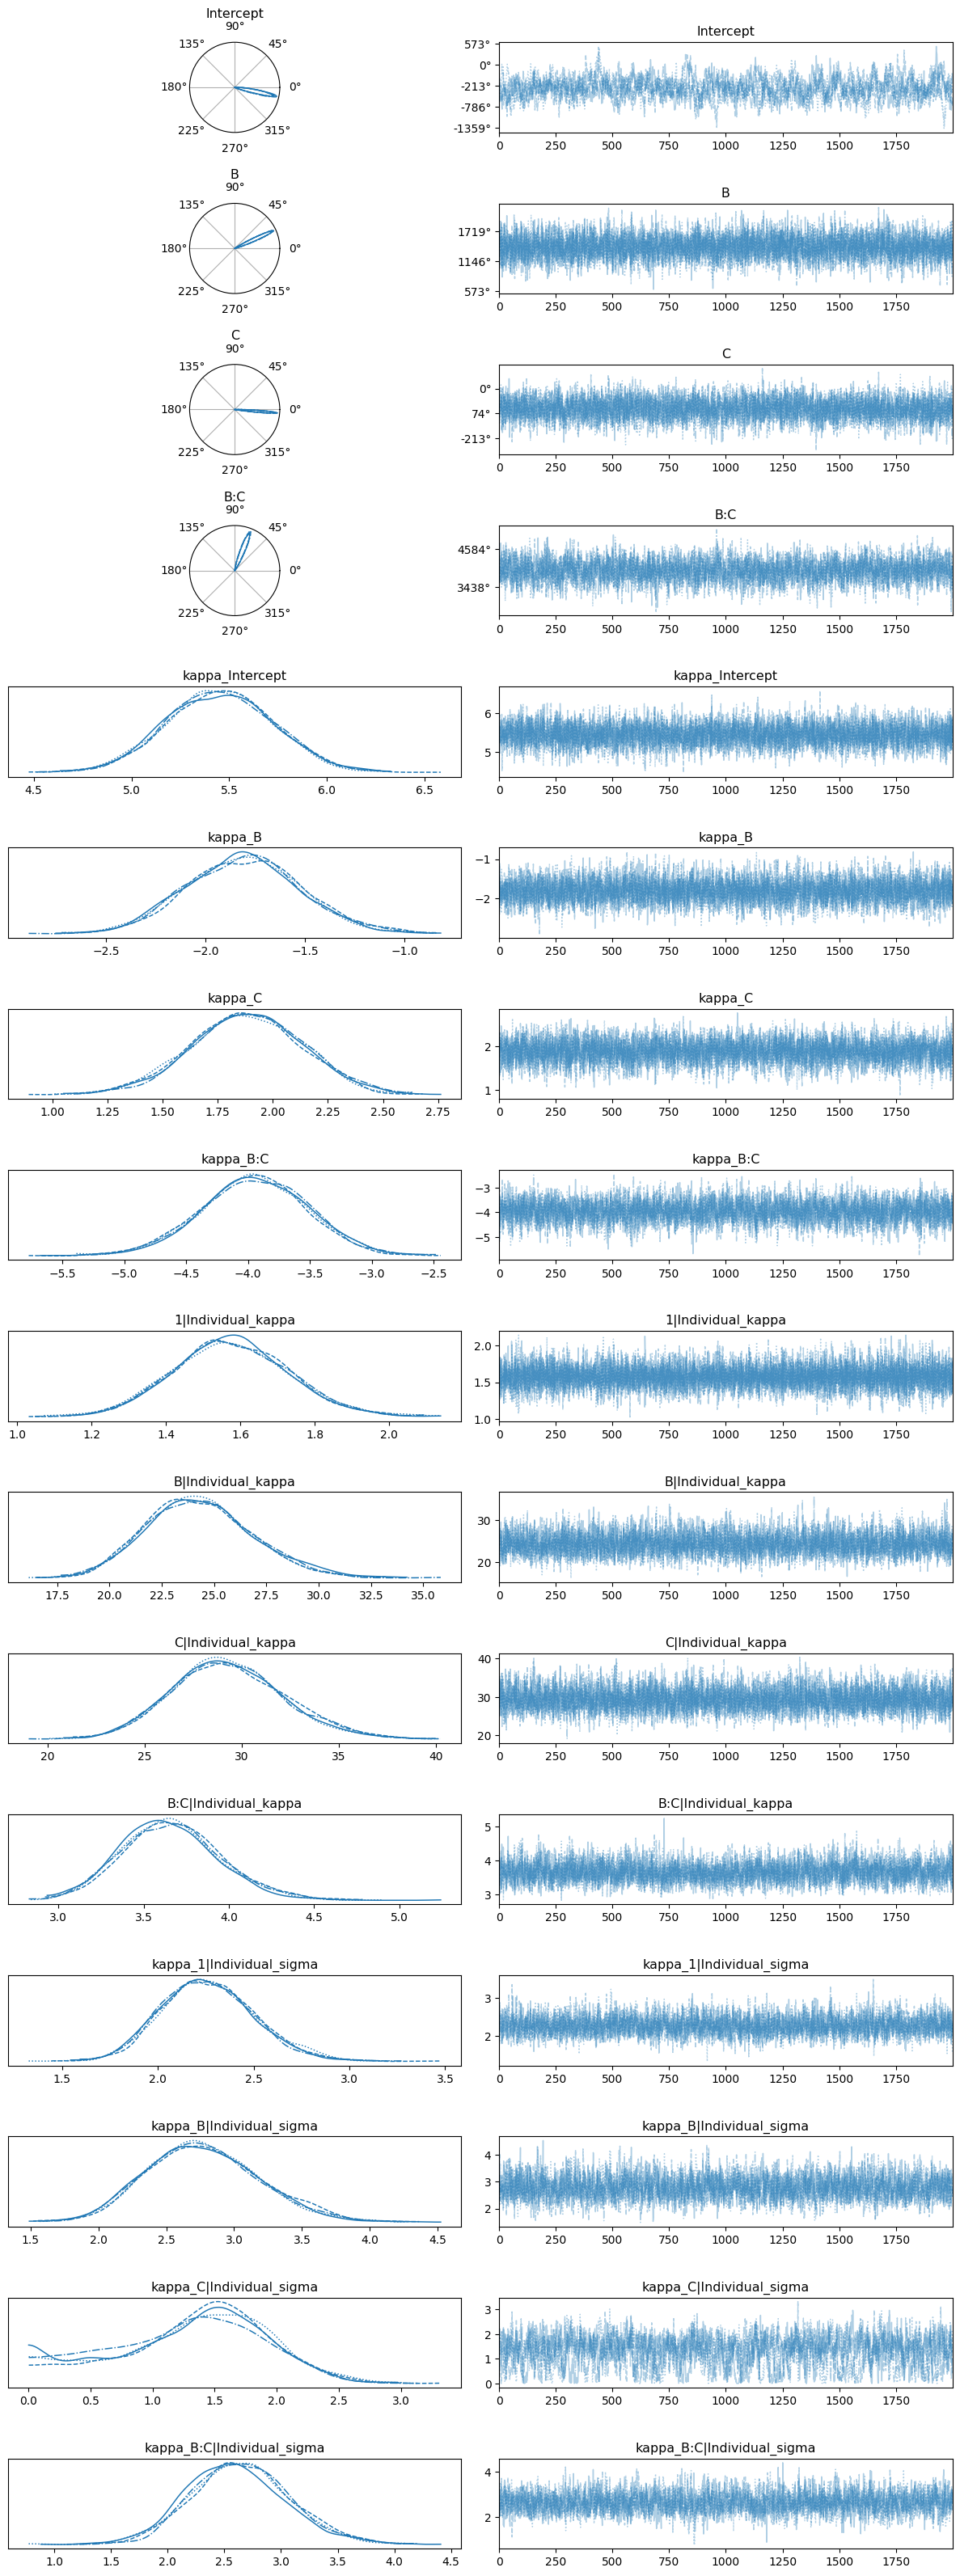

In [17]:
plot_circular_trace(
                    idata = idata,
                    vars=[
                             "Intercept",
                            "B",
                            "C",
                            "B:C",
                            "kappa_Intercept",
                            "kappa_B",
                            "kappa_C",
                            "kappa_B:C",
                            "1|Individual_kappa",
                            "B|Individual_kappa",
                            "C|Individual_kappa",
                            "B:C|Individual_kappa",
                            "kappa_1|Individual_sigma",
                            "kappa_B|Individual_sigma",
                            "kappa_C|Individual_sigma",
                            "kappa_B:C|Individual_sigma",
                        ],
                    cvars = ["Intercept",
                            "B",
                            "C",
                            "B:C",
                            ]
)

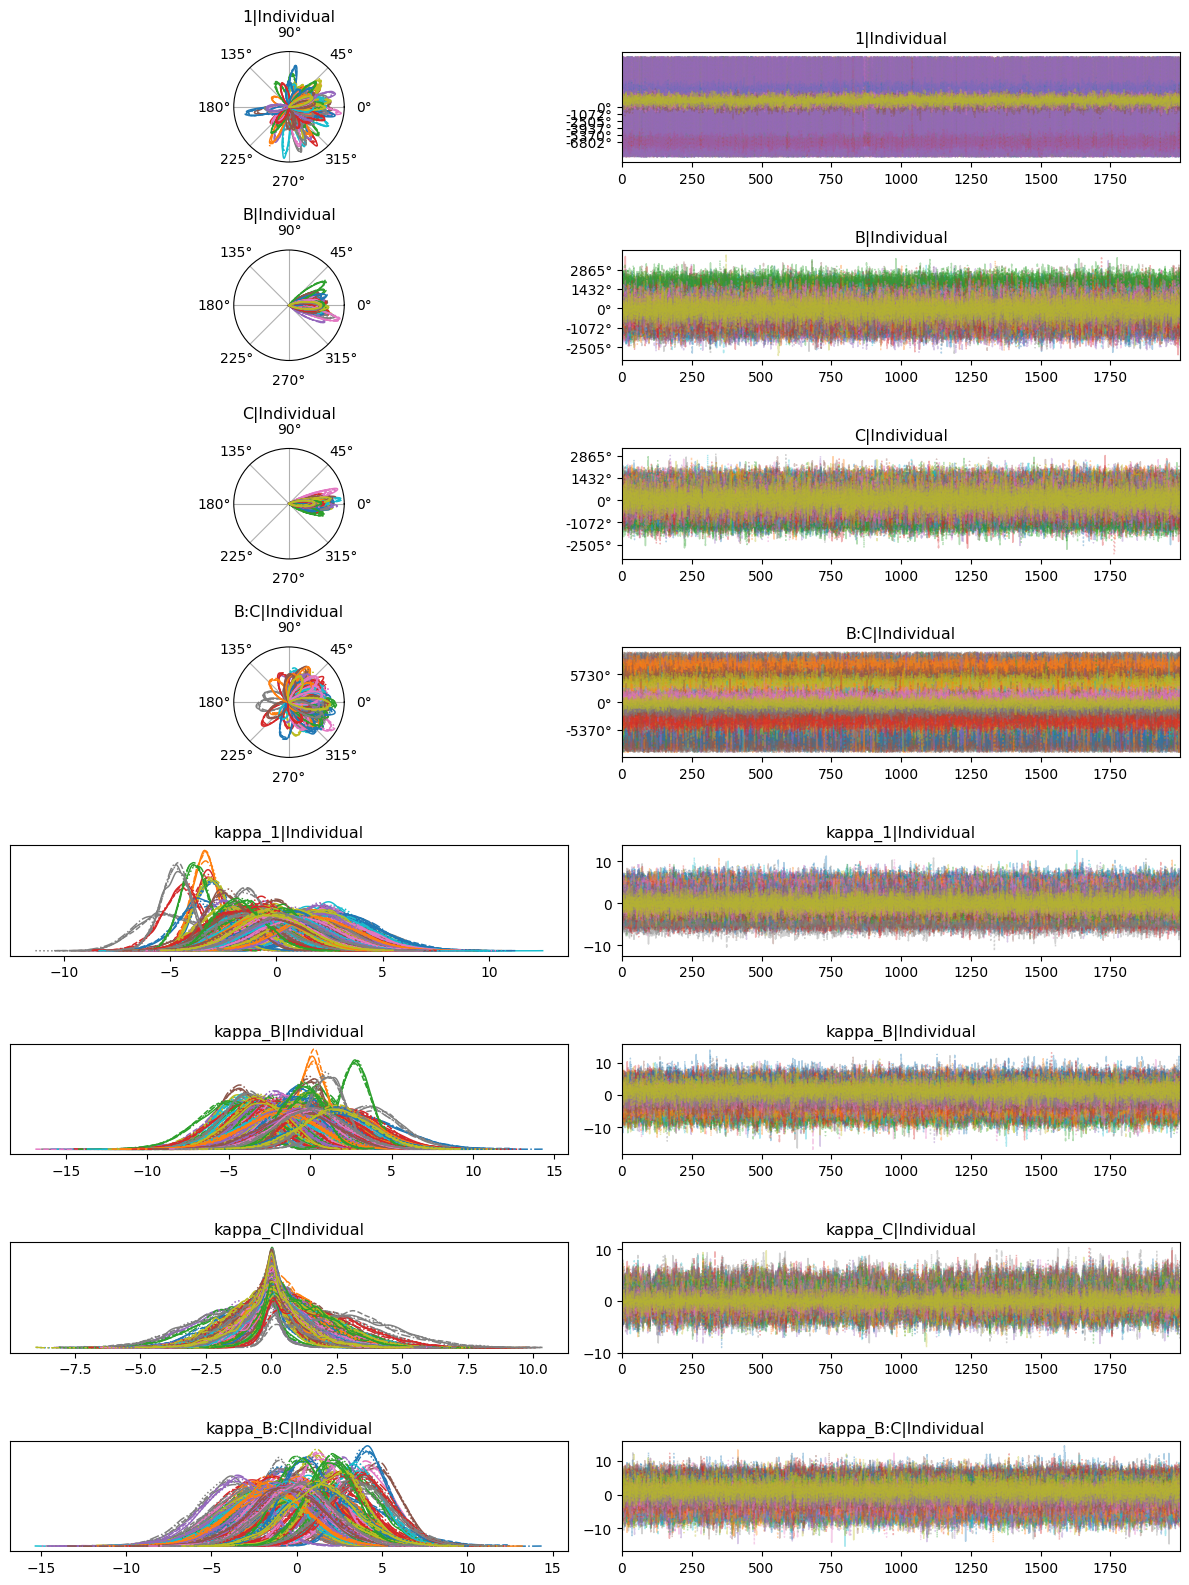

In [18]:
plot_circular_trace(
                    idata = idata,
vars=[
        "1|Individual",
        "B|Individual",
        "C|Individual",
        "B:C|Individual",
        "kappa_1|Individual",
        "kappa_B|Individual",
        "kappa_C|Individual",
        "kappa_B:C|Individual",
       ],
cvars = [
        "1|Individual",
        "B|Individual",
        "C|Individual",
        "B:C|Individual",
        ]
)

# Model comparison
We would like to test multiple hypotheses about the data:
1. Can all differences be explained by stimulus colour?
    - UV effect
2. Can all differences be explained by stimulus brightness?
    - dim effect
3. Does brightness affect accuracy?
    - $\mu \sim$ colour
    - $\kappa \sim$ colour & brightness
4. Does colour affect accuracy?
    - $\mu \sim$ brightness
    - $\kappa \sim$ colour & brightness
5. Can differences be explained by the combined effects of colour and brightness?
    - $\mu \sim$ colour & brightness
    - $\kappa \sim$ colour & brightness
6. Is concentration specific to each combinations of colour and brightness?
    - $\mu \sim$ colour & brightness
    - $\kappa \sim$ colour, brightness & their interaction
7. Is all information about specific combinations of colour and brightness required to explain the data?
    - $\mu \sim$ colour, brightness & their interaction
    - $\kappa \sim$ colour, brightness & their interaction


## Set up alternative models

In [24]:
import bambi as bmb
# Define the model formulas
#model 1
formula_UV = bmb.Formula(
    "angle ~ C + (1 + C |Individual)",
    "kappa ~ C + (1 + C |Individual)",
)

#model 2
formula_dim = bmb.Formula(
    "angle ~ B + (1 + B |Individual)",
    "kappa ~ B + (1 + B |Individual)",
)

#model 3
formula_UV_dimKappa = bmb.Formula(
    "angle ~ C + (1 + C |Individual)",
    "kappa ~ B + C + (1 + B + C |Individual)",
)

#model 4
formula_dim_UVKappa = bmb.Formula(
    "angle ~ B + (1 + B |Individual)",
    "kappa ~ B + C + (1 + B + C |Individual)",
)

#model 5
formula_additive = bmb.Formula(
    "angle ~ B + C + (1 + B + C |Individual)",
    "kappa ~ B + C + (1 + B + C |Individual)",
)

#model 6
formula_additive_interactionKappa = bmb.Formula(
    "angle ~ B + C + (1 + B + C |Individual)",
    "kappa ~ B + C + B:C + (1 + B + C + B:C |Individual)",
)

#model 7 already fitted
    # "angle ~ B + C + B:C + (1 + B + C + B:C |Individual)",
    # "kappa ~ B + C + B:C + (1 + B + C + B:C |Individual)",



In [25]:
from unwrap.link.bambi import LINKS
from unwrap.link.numpy import inverse_softplus
from unwrap.prior import CircularUniformPrior
from pymc import VonMises

# Define the model priors
#model 1
priors_UV = {
    # Fixed effects for μ:
    "Intercept": CircularUniformPrior(),
    # "Intercept": bmb.Prior("VonMises", mu=0, kappa=3), # 
    "C": bmb.Prior("Normal", mu=0, sigma=np.pi/12), # 
    # Individual-level effects for μ:
    "1|Individual": bmb.Prior(
        "VonMises", mu=0, kappa=bmb.Prior("LogNormal", mu=np.log(30), sigma=0.60) #
    ),
    "C|Individual": bmb.Prior(
        "VonMises", mu=0, kappa=bmb.Prior("LogNormal", mu=np.log(100), sigma=0.60) #
    ),
    # Priors for the κ-model (inside the "kappa" dictionary):
    "kappa": {
        # Fixed effects for κ:
        "Intercept": bmb.Prior("Normal", mu=inverse_softplus(3), sigma=0.5), # 
        "C": bmb.Prior("Normal", mu=0, sigma=1.0), # Works
        # Individual-level effects for κ:
        "1|Individual": bmb.Prior(
            "Normal", mu=0, sigma=bmb.Prior("HalfStudentT", nu=3, sigma=1.0) #
        ),
        "C|Individual": bmb.Prior(
            "Normal", mu=0, sigma=bmb.Prior("HalfStudentT", nu=3, sigma=1.0) #
        ),
    },
}

#model 2
priors_dim = {
    # Fixed effects for μ:
    "Intercept": CircularUniformPrior(),
    "B": bmb.Prior("Normal", mu=0, sigma=np.pi/12), # 
    # Individual-level effects for μ: #
    "1|Individual": bmb.Prior(
        "VonMises", mu=0, kappa=bmb.Prior("LogNormal", mu=np.log(30), sigma=0.60) # 
    ),
    "B|Individual": bmb.Prior(
        "VonMises", mu=0, kappa=bmb.Prior("LogNormal", mu=np.log(100), sigma=0.60) # 
    ),
    # Priors for the κ-model (inside the "kappa" dictionary):
    "kappa": {
        # Fixed effects for κ:
        "Intercept": bmb.Prior("Normal", mu=inverse_softplus(3), sigma=0.5), # 
        "B": bmb.Prior("Normal", mu=0, sigma=0.3), # 
        # Individual-level effects for κ:
        "1|Individual": bmb.Prior(
            "Normal", mu=0, sigma=bmb.Prior("HalfStudentT", nu=3, sigma=0.5) #
        ),
        "B|Individual": bmb.Prior(
            "Normal", mu=0, sigma=bmb.Prior("HalfStudentT", nu=3, sigma=0.3) #
        ),
    },
}

#model 3
priors_UV_dimKappa = {
    # μ Model (Only C)
    "Intercept": CircularUniformPrior(),
    "C": bmb.Prior("Normal", mu=0, sigma=np.pi/12),
    "1|Individual": bmb.Prior(
        "VonMises", mu=0, kappa=bmb.Prior("LogNormal", mu=np.log(30), sigma=0.60)
    ),
    "C|Individual": bmb.Prior(
        "VonMises", mu=0, kappa=bmb.Prior("LogNormal", mu=np.log(30), sigma=0.10)
    ),
    # κ Model (B and C)
    "kappa": {
        "Intercept": bmb.Prior("Normal", mu=inverse_softplus(3), sigma=0.5),
        "B": bmb.Prior("Normal", mu=0, sigma=0.3),
        "C": bmb.Prior("Normal", mu=0, sigma=0.3),
        "1|Individual": bmb.Prior(
            "Normal", mu=0, sigma=bmb.Prior("HalfStudentT", nu=3, sigma=0.5)
        ),
        "B|Individual": bmb.Prior(
            "Normal", mu=0, sigma=bmb.Prior("HalfStudentT", nu=3, sigma=0.3)
        ),
        "C|Individual": bmb.Prior(
            "Normal", mu=0, sigma=bmb.Prior("HalfStudentT", nu=3, sigma=0.3)
        ),
    },
}

#model 4
priors_dim_UVKappa = {
    # μ Model (Only B)
   "Intercept": CircularUniformPrior(),
    "B": bmb.Prior("Normal", mu=0, sigma=np.pi/12),
    "1|Individual": bmb.Prior(
        "VonMises", mu=0, kappa=bmb.Prior("LogNormal", mu=np.log(30), sigma=0.60)
    ),
    "B|Individual": bmb.Prior(
        "VonMises", mu=0, kappa=bmb.Prior("LogNormal", mu=np.log(30), sigma=0.10)
    ),
    # κ Model (B and C)
    "kappa": {
        "Intercept": bmb.Prior("Normal", mu=inverse_softplus(3), sigma=0.5),
        "B": bmb.Prior("Normal", mu=0, sigma=0.3),
        "C": bmb.Prior("Normal", mu=0, sigma=0.3),
        "1|Individual": bmb.Prior(
            "Normal", mu=0, sigma=bmb.Prior("HalfStudentT", nu=3, sigma=0.5)
        ),
        "B|Individual": bmb.Prior(
            "Normal", mu=0, sigma=bmb.Prior("HalfStudentT", nu=3, sigma=0.3)
        ),
        "C|Individual": bmb.Prior(
            "Normal", mu=0, sigma=bmb.Prior("HalfStudentT", nu=3, sigma=0.3)
        ),
    },
}

#model 5
priors_additive = {
    # Fixed effects for μ (Angle):
    "Intercept": CircularUniformPrior(),
    "B": bmb.Prior("Normal", mu=0, sigma=np.pi/12),
    "C": bmb.Prior("Normal", mu=0, sigma=np.pi/12),
    
    # Individual-level effects for μ:
    "1|Individual": bmb.Prior(
        "VonMises", mu=0, kappa=bmb.Prior("LogNormal", mu=np.log(30), sigma=0.60)
    ),
    "B|Individual": bmb.Prior(
        "VonMises", mu=0, kappa=bmb.Prior("LogNormal", mu=np.log(30), sigma=0.10)
    ),
    "C|Individual": bmb.Prior(
        "VonMises", mu=0, kappa=bmb.Prior("LogNormal", mu=np.log(30), sigma=0.10)
    ),
    
    # Priors for the κ-model:
    "kappa": {
        # Fixed effects for κ:
        "Intercept": bmb.Prior("Normal", mu=inverse_softplus(3), sigma=0.5),
        "B": bmb.Prior("Normal", mu=0, sigma=0.3),
        "C": bmb.Prior("Normal", mu=0, sigma=0.3),
        
        # Individual-level effects for κ:
        "1|Individual": bmb.Prior(
            "Normal", mu=0, sigma=bmb.Prior("HalfStudentT", nu=3, sigma=0.5)
        ),
        "B|Individual": bmb.Prior(
            "Normal", mu=0, sigma=bmb.Prior("HalfStudentT", nu=3, sigma=0.3)
        ),
        "C|Individual": bmb.Prior(
            "Normal", mu=0, sigma=bmb.Prior("HalfStudentT", nu=3, sigma=0.3)
        ),
    },
}

priors_additive_interactionKappa = {
    # μ Model: Additive (B + C)
    "Intercept": CircularUniformPrior(),
    "B": bmb.Prior("Normal", mu=0, sigma=np.pi/12),
    "C": bmb.Prior("Normal", mu=0, sigma=np.pi/12),
    
    "1|Individual": bmb.Prior(
        "VonMises", mu=0, kappa=bmb.Prior("LogNormal", mu=np.log(30), sigma=0.60)
    ),
    "B|Individual": bmb.Prior(
        "VonMises", mu=0, kappa=bmb.Prior("LogNormal", mu=np.log(30), sigma=0.10)
    ),
    "C|Individual": bmb.Prior(
        "VonMises", mu=0, kappa=bmb.Prior("LogNormal", mu=np.log(30), sigma=0.10)
    ),
    
    # κ Model: Interaction (B + C + B:C)
    "kappa": {
        "Intercept": bmb.Prior("Normal", mu=inverse_softplus(3), sigma=0.5),
        "B": bmb.Prior("Normal", mu=0, sigma=0.3),
        "C": bmb.Prior("Normal", mu=0, sigma=0.3),
        "B:C": bmb.Prior("Normal", mu=0, sigma=0.2), # Interaction fixed effect
        
        "1|Individual": bmb.Prior(
            "Normal", mu=0, sigma=bmb.Prior("HalfStudentT", nu=3, sigma=0.5)
        ),
        "B|Individual": bmb.Prior(
            "Normal", mu=0, sigma=bmb.Prior("HalfStudentT", nu=3, sigma=0.3)
        ),
        "C|Individual": bmb.Prior(
            "Normal", mu=0, sigma=bmb.Prior("HalfStudentT", nu=3, sigma=0.3)
        ),
        "B:C|Individual": bmb.Prior(
            "Normal", mu=0, sigma=bmb.Prior("HalfStudentT", nu=3, sigma=0.5)
        ),
    },
}

In [27]:

# Prepare all models
#model 1
model_UV = bmb.Model(
    formula_UV,
    df,
    family="vonmises",
    priors=priors_UV,
    link={"mu": LINKS["shifted_modulo"], "kappa": LINKS["softplus"]},
    center_predictors=False,
    dropna=True,
)

#model 2
model_dim = bmb.Model(
    formula_dim,
    df,
    family="vonmises",
    priors=priors_dim,
    link={"mu": LINKS["shifted_modulo"], "kappa": LINKS["softplus"]},
    center_predictors=False,
    dropna=True,
)

#model 3
model_UV_dimKappa = bmb.Model(
    formula_UV_dimKappa,
    df,
    family="vonmises",
    priors=priors_UV_dimKappa,
    link={"mu": LINKS["shifted_modulo"], "kappa": LINKS["softplus"]},
    center_predictors=False,
    dropna=True,
)

#model 4
model_dim_UVKappa = bmb.Model(
    formula_dim_UVKappa,
    df,
    family="vonmises",
    priors=priors_dim_UVKappa,
    link={"mu": LINKS["shifted_modulo"], "kappa": LINKS["softplus"]},
    center_predictors=False,
    dropna=True,
)

#model 5
model_additive = bmb.Model(
    formula_additive,
    df,
    family="vonmises",
    priors=priors_additive,
    link={"mu": LINKS["shifted_modulo"], "kappa": LINKS["softplus"]},
    center_predictors=False,
    dropna=True,
)

#model 6
model_additive_interactionKappa = bmb.Model(
    formula_additive_interactionKappa,
    df,
    family="vonmises",
    priors=priors_additive_interactionKappa,
    link={"mu": LINKS["shifted_modulo"], "kappa": LINKS["softplus"]},
    center_predictors=False,
    dropna=True,
)

## Run model 1
UV (C only)

In [ ]:
import numpy as np
import pandas as pd
import bambi as bmb
import arviz as az
import matplotlib.pyplot as plt

# Fit the model.
idata_UV = model_UV.fit(draws= 1000,#longer run for mu convergence
                  tune = 1000,
                  progressbar="split+stats",
                  idata_kwargs={"log_likelihood": True},
                #   target_accept= 0.9  # For prior testing
                  target_accept= 0.98  # Needs sampling with small steps or generates some divergences 0.95 works
        ) # be prepared for this to take 90 minutes with high adapt delta
#check convergence heuristics
az.summary(
    idata_UV, 
    var_names=["Intercept", #slightly right shifted, should converge to around 0.26
               "C", 
               "kappa_Intercept",
               "kappa_C",
                ],
    circ_var_names=["Intercept",
                    "C",
                    ]
)


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, C, 1|Individual_kappa, 1|Individual, C|Individual_kappa, C|Individual, kappa_Intercept, kappa_C, kappa_1|Individual_sigma, kappa_1|Individual_offset, kappa_C|Individual_sigma, kappa_C|Individual_offset]


Output()

In [ ]:
#check convergence heuristics on random effects
az.summary(
    idata_UV, 
    var_names=[
        "1|Individual_kappa",
        "C|Individual_kappa",
        "kappa_1|Individual_sigma",
        "kappa_C|Individual_sigma",
                ],
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
1|Individual_kappa,1.248,0.139,0.995,1.496,0.018,0.007,58.0,195.0,1.05
C|Individual_kappa,19.869,5.889,10.905,30.983,2.078,0.383,8.0,43.0,1.43
kappa_1|Individual_sigma,1.667,0.140,1.446,1.967,0.029,0.011,26.0,73.0,1.12
kappa_C|Individual_sigma,1.612,0.160,1.336,1.931,0.034,0.009,25.0,112.0,1.14


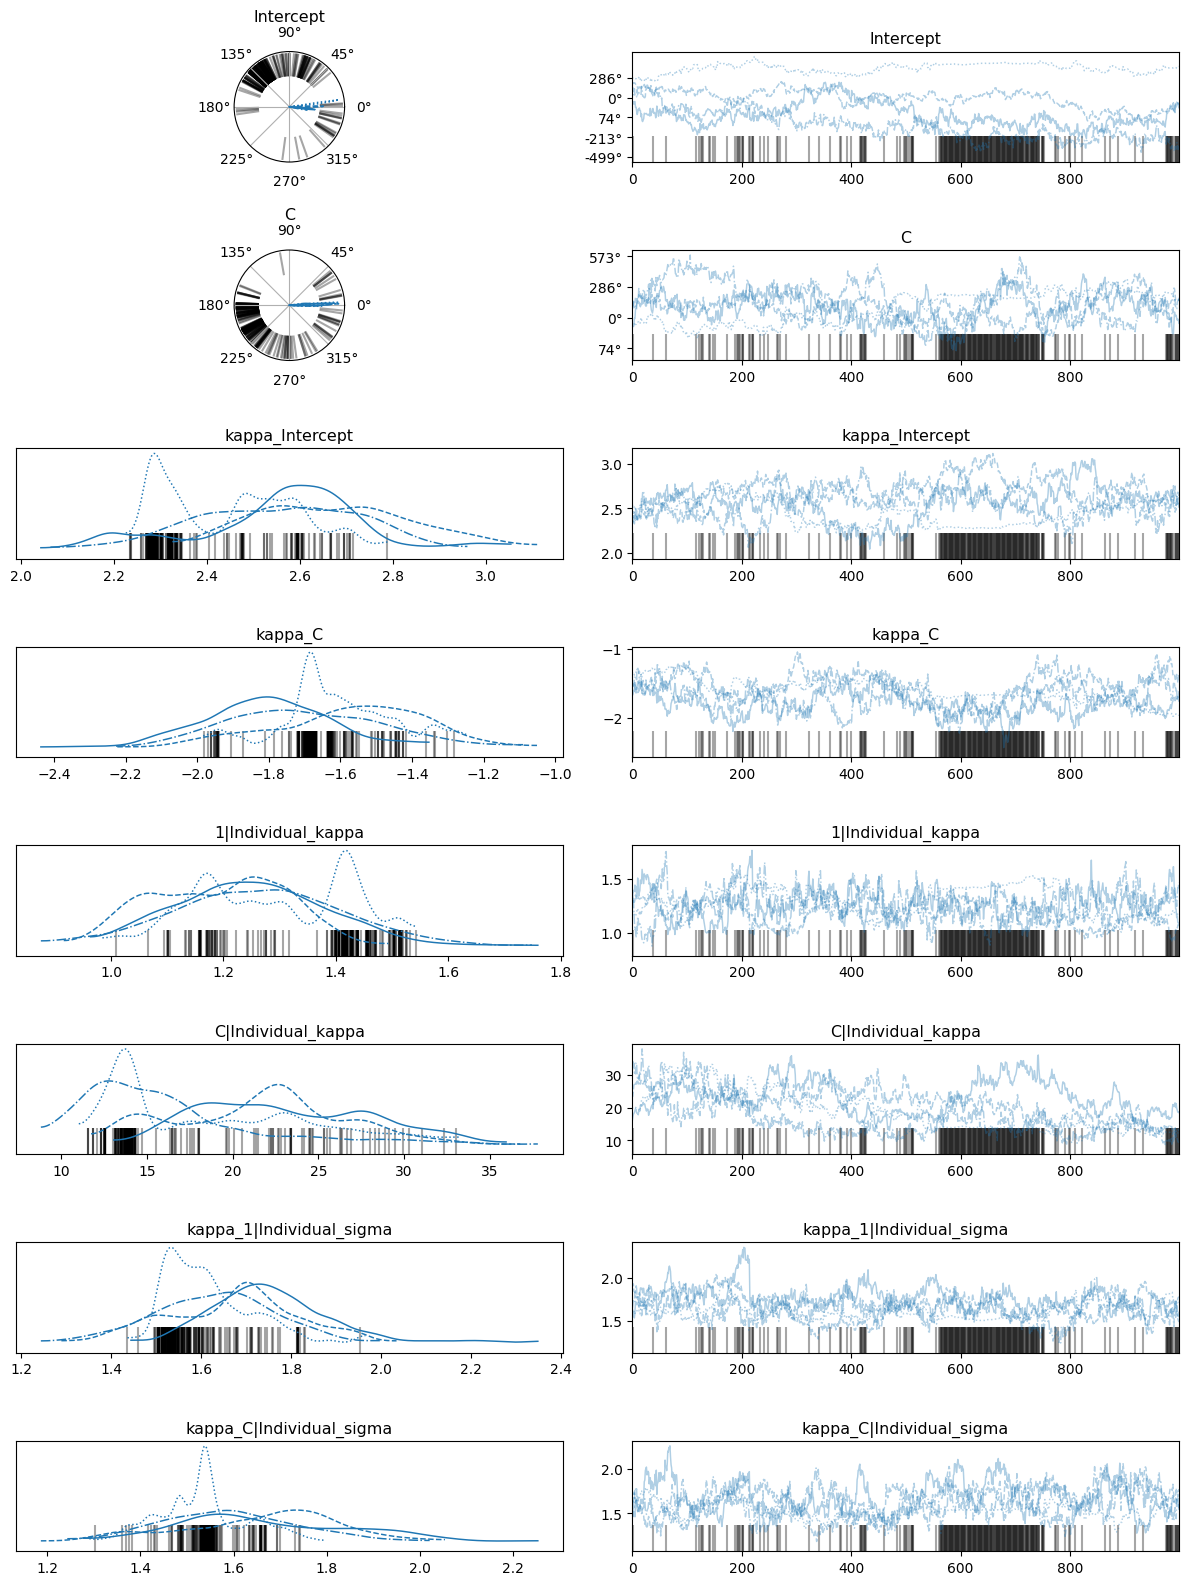

In [ ]:
plot_circular_trace(
                    idata = idata_UV,
                    vars=[
                            "Intercept",
                            "C",
                            "kappa_Intercept",
                            "kappa_C",
                            "1|Individual_kappa",
                            "C|Individual_kappa",
                            "kappa_1|Individual_sigma",
                            "kappa_C|Individual_sigma",
                        ],
                    cvars = ["Intercept",
                            "C",
                            ]
)

## Run model 2
dim (B only)


In [ ]:
# Fit the model.
idata_dim = model_dim.fit(draws= 2000,#longer run for mu convergence
                  tune = 1000,
                  progressbar="split+stats",
                  idata_kwargs={"log_likelihood": True},
                  target_accept= 0.98  # Needs sampling with small steps or generates some divergences 0.95 works
        ) # be prepared for this to take 90 minutes with high adapt delta
#check convergence heuristics
az.summary(
    idata_dim, 
    var_names=["Intercept", #slightly right shifted, should converge to around 0.26
               "B", 
                "kappa_Intercept",
               "kappa_B",
                ],
    circ_var_names=["Intercept",
                    "B",
                    ]
)


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, B, 1|Individual_kappa, 1|Individual, B|Individual_kappa, B|Individual, kappa_Intercept, kappa_B, kappa_1|Individual_sigma, kappa_1|Individual_offset, kappa_B|Individual_sigma, kappa_B|Individual_offset]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 6714 seconds.
There were 423 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,0.216,0.038,0.145,0.278,0.012,0.007,6.0,21.0,1.81
B,-1.214,0.129,-1.391,-1.019,0.049,0.011,6.0,12.0,1.92
kappa_Intercept,6.368,0.258,5.889,6.819,0.079,0.027,11.0,24.0,1.30
kappa_B,-2.521,0.376,-3.116,-1.831,0.128,0.033,9.0,63.0,1.36


In [ ]:
#check convergence heuristics on random effects
az.summary(
    idata_dim, 
    var_names=[
        "1|Individual_kappa",
        "B|Individual_kappa",
        "kappa_1|Individual_sigma",
        "kappa_"
        "B|Individual_sigma",
                ],
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
1|Individual_kappa,1.575,0.147,1.321,1.854,0.016,0.006,84.0,186.0,1.06
B|Individual_kappa,1.179,0.146,0.895,1.457,0.015,0.008,93.0,206.0,1.05
kappa_1|Individual_sigma,2.186,0.231,1.721,2.640,0.037,0.035,42.0,56.0,1.16
kappa_B|Individual_sigma,4.246,0.614,3.239,5.365,0.206,0.055,9.0,37.0,1.36


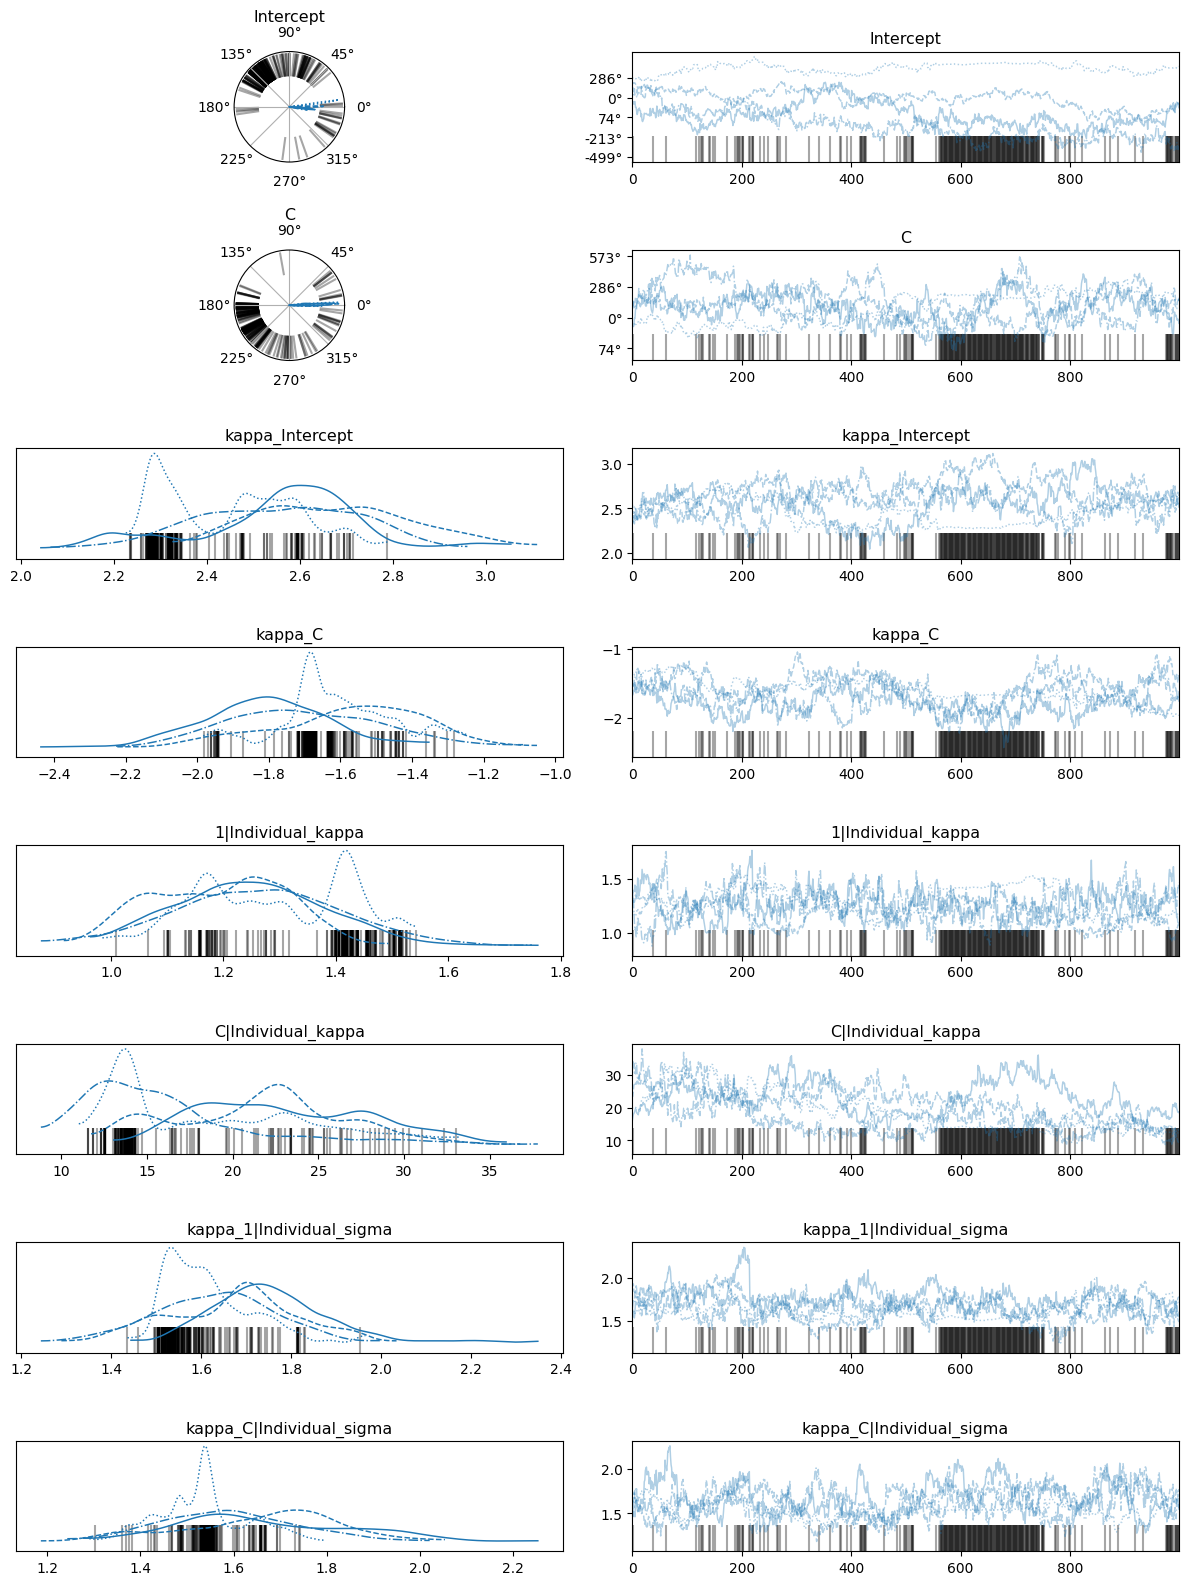

In [ ]:
plot_circular_trace(
                    idata = idata_dim,
                    vars=[
                            "Intercept",
                            "B",
                            "kappa_Intercept",
                            "kappa_B",
                            "1|Individual_kappa",
                            "b|Individual_kappa",
                            "kappa_1|Individual_sigma",
                            "kappa_B|Individual_sigma",
                        ],
                    cvars = ["Intercept",
                            "B",
                            ]
)

## Run model 3
UV_dimKappa (angle ~ C, kappa ~ B + C)

In [ ]:
# Fit the model.
idata_UV_dimKappa = model_UV_dimKappa.fit(draws= 2000,#longer run for mu convergence
                                          tune=1000, 
                                          progressbar="split+stats", 
                                          idata_kwargs={"log_likelihood": True}, 
                                          target_accept=0.98)

# Fixed effects summary
az.summary(idata_UV_dimKappa, 
    var_names=["Intercept", 
               "C", 
               "kappa_Intercept", 
               "kappa_B", 
               "kappa_C"],
    circ_var_names=["Intercept", 
                    "C"])



Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...


In [ ]:
# Random effects summary
az.summary(idata_UV_dimKappa, 
    var_names=["1|Individual_kappa", 
               "C|Individual_kappa", 
               "kappa_1|Individual_sigma", 
               "kappa_B|Individual_sigma", 
               "kappa_C|Individual_sigma"])

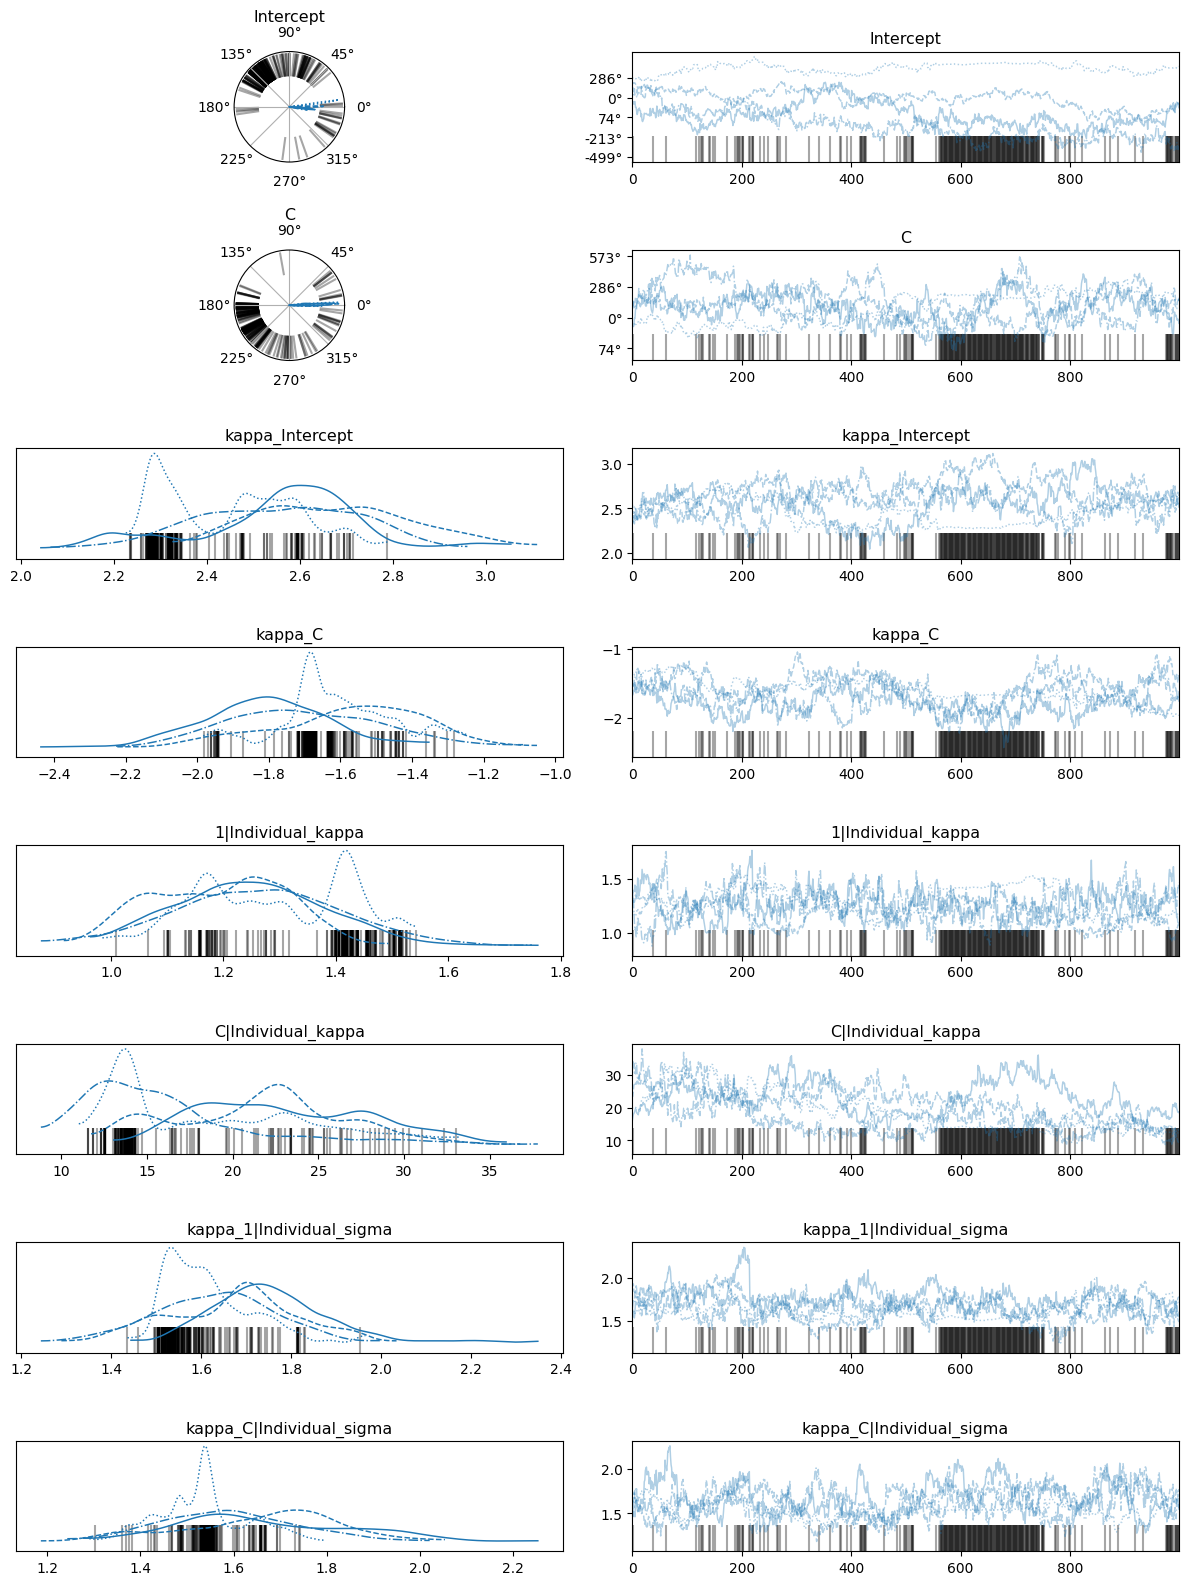

In [ ]:
plot_circular_trace(
                    idata = idata_UV_dimKappa,
                    vars=[
                            "Intercept",
                            "C",
                            "kappa_Intercept",
                            "kappa_C",
                            "kappa_B",
                            "1|Individual_kappa",
                            "C|Individual_kappa",
                            "kappa_1|Individual_sigma",
                            "kappa_C|Individual_sigma",
                            "kappa_B|Individual_sigma",
                        ],
                    cvars = ["Intercept",
                            "C",
                            ]
)

## Run model 4
Dim_UVKappa (angle ~ B, kappa ~ B + C)

In [ ]:
# Fit the model.
idata_dim_UVKappa = model_dim_UVKappa.fit(draws= 2000,#longer run for mu convergence
                                          tune=1000, 
                                          progressbar="split+stats", 
                                          idata_kwargs={"log_likelihood": True}, 
                                          target_accept=0.98)

# Fixed effects summary
az.summary(idata_dim_UVKappa, 
    var_names=["Intercept", 
               "B", 
               "kappa_Intercept",
                "kappa_B", 
                "kappa_C"],
    circ_var_names=["Intercept", 
                    "B"])



In [ ]:
# Random effects summary
az.summary(idata_dim_UVKappa, 
    var_names=["1|Individual_kappa", 
               "B|Individual_kappa", 
               "kappa_1|Individual_sigma", 
               "kappa_B|Individual_sigma", 
               "kappa_C|Individual_sigma"])

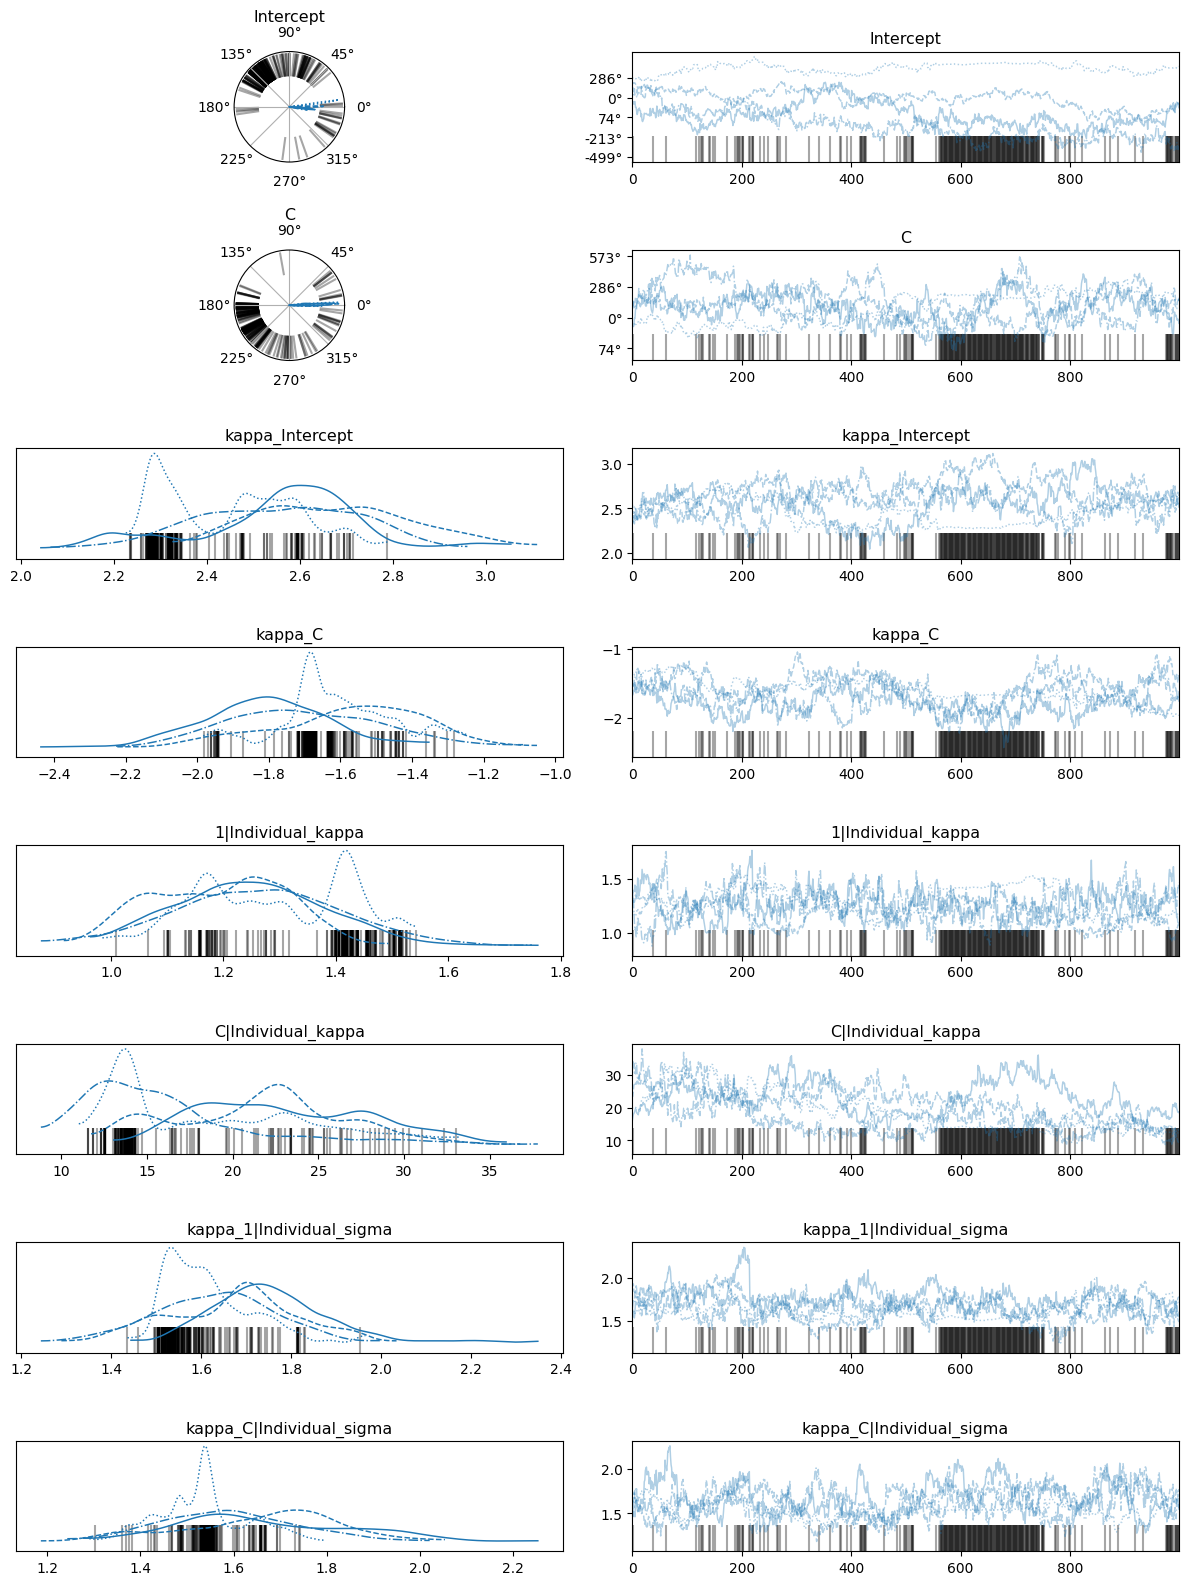

In [ ]:
plot_circular_trace(
                    idata = idata_dim_UVkappa,
                    vars=[
                            "Intercept",
                            "B",
                            "kappa_Intercept",
                            "kappa_C",
                            "kappa_B",
                            "1|Individual_kappa",
                            "B|Individual_kappa",
                            "kappa_1|Individual_sigma",
                            "kappa_C|Individual_sigma",
                            "kappa_B|Individual_sigma",
                        ],
                    cvars = ["Intercept",
                            "B",
                            ]
)

## Run model 5
Additive (B + C on both)

In [ ]:
# Fit the model.
idata_additive = model_additive.fit(draws= 2000,#longer run for mu convergence
                                    tune=1000, 
                                    progressbar="split+stats", 
                                    idata_kwargs={"log_likelihood": True}, 
                                    target_accept=0.98)

# Fixed effects summary
az.summary(idata_additive, 
    var_names=["Intercept", 
               "B", 
               "C", 
               "kappa_Intercept", 
               "kappa_B", 
               "kappa_C"],
    circ_var_names=["Intercept", 
                    "B", 
                    "C"])



In [ ]:
# Random effects summary
az.summary(idata_additive, 
    var_names=["1|Individual_kappa", 
               "B|Individual_kappa", 
               "C|Individual_kappa", 
               "kappa_1|Individual_sigma", 
               "kappa_B|Individual_sigma", 
               "kappa_C|Individual_sigma"])

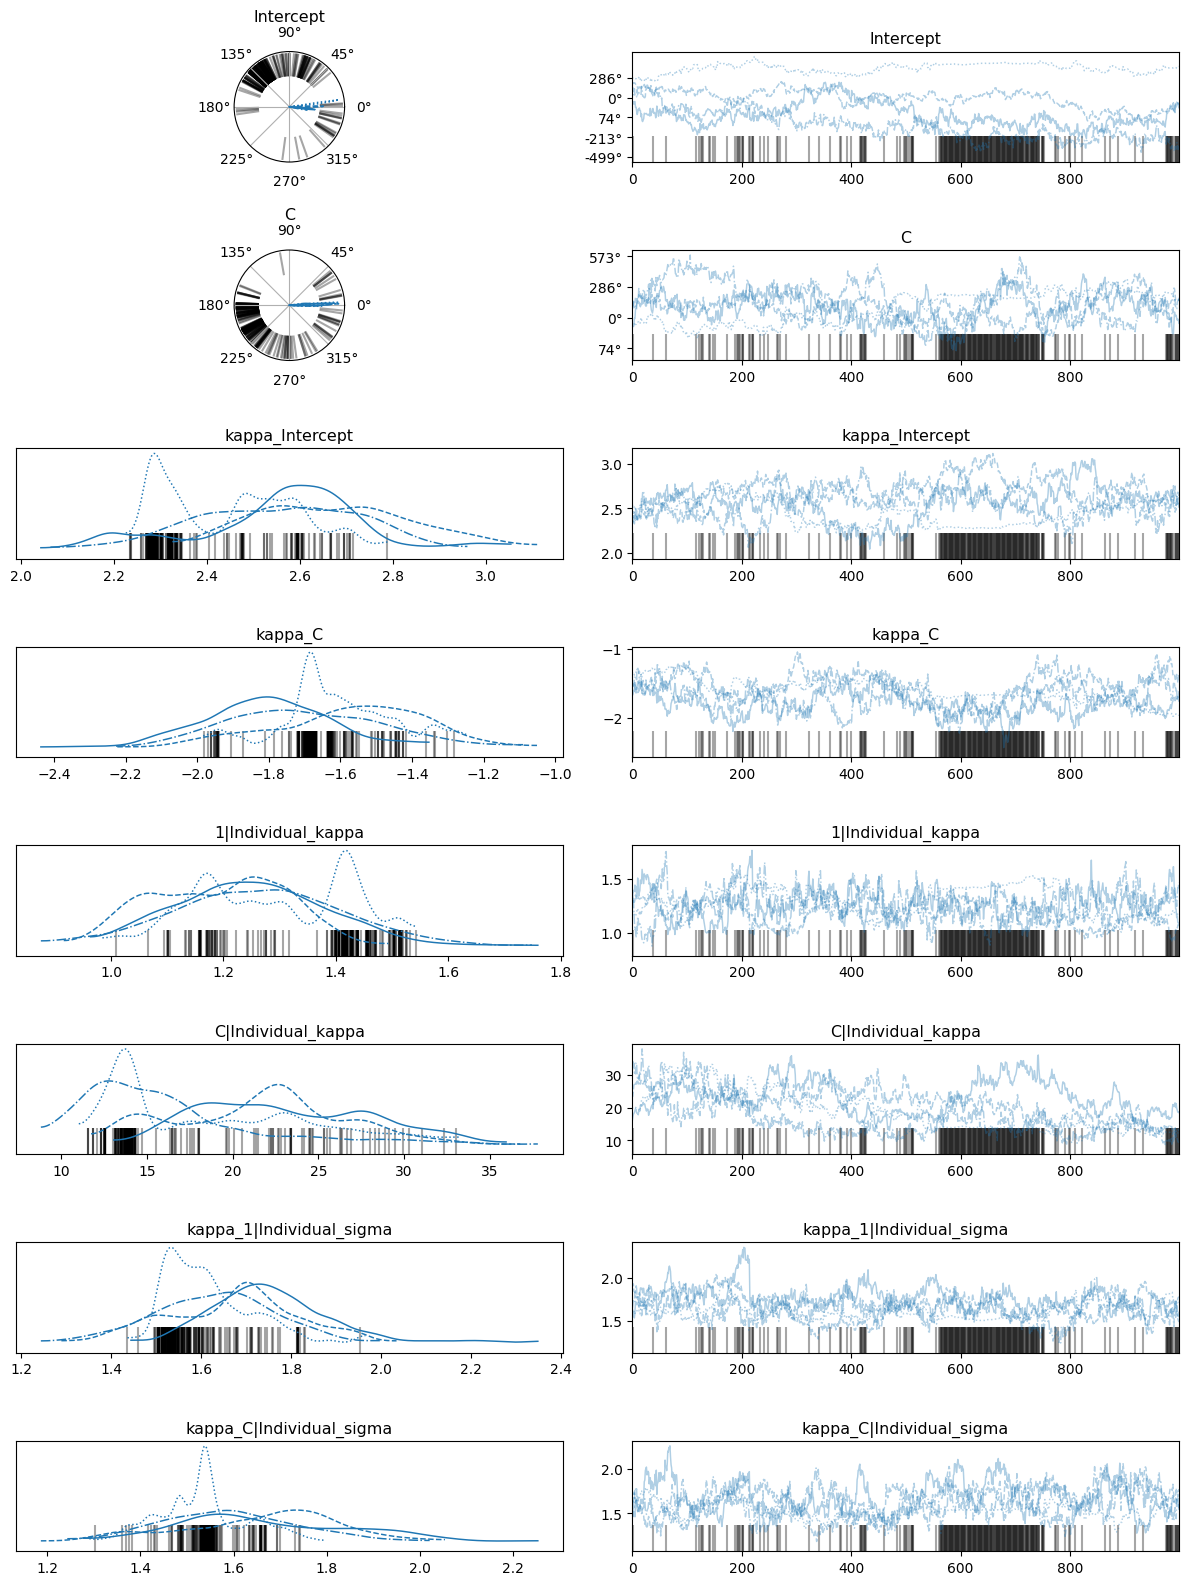

In [ ]:
plot_circular_trace(
                    idata = idata_additive,
                    vars=[
                            "Intercept",
                            "C",
                            "B",
                            "kappa_Intercept",
                            "kappa_C",
                            "kappa_B",
                            "1|Individual_kappa",
                            "C|Individual_kappa",
                            "B|Individual_kappa",
                            "kappa_1|Individual_sigma",
                            "kappa_C|Individual_sigma",
                            "kappa_B|Individual_sigma",
                        ],
                    cvars = ["Intercept",
                            "C",
                            "B",
                            ]
)

## Run model 6
$\mu$ additive (B + C), $\kappa$ interaction  (B * C)

In [ ]:
# Fit the model.
idata_additive_interactionKappa = model_additive_interactionKappa.fit(draws= 2000,#longer run for mu convergence
                                    tune=1000, 
                                    progressbar="split+stats", 
                                    idata_kwargs={"log_likelihood": True}, 
                                    target_accept=0.98)

# Fixed effects summary
az.summary(idata_additive_interactionKappa, 
    var_names=["Intercept", 
               "B", 
               "C", 
               "kappa_Intercept", 
               "kappa_B", 
               "kappa_C",
               "kappa_B:C",
               ],
    circ_var_names=["Intercept", 
                    "B", 
                    "C"])

In [ ]:
# Random effects summary
az.summary(idata_additive_interactionKappa, 
    var_names=["1|Individual_kappa", 
               "B|Individual_kappa", 
               "C|Individual_kappa", 
               "kappa_1|Individual_sigma", 
               "kappa_B|Individual_sigma", 
               "kappa_C|Individual_sigma",
               "kappa_B:C|Individual_sigma",
               ])

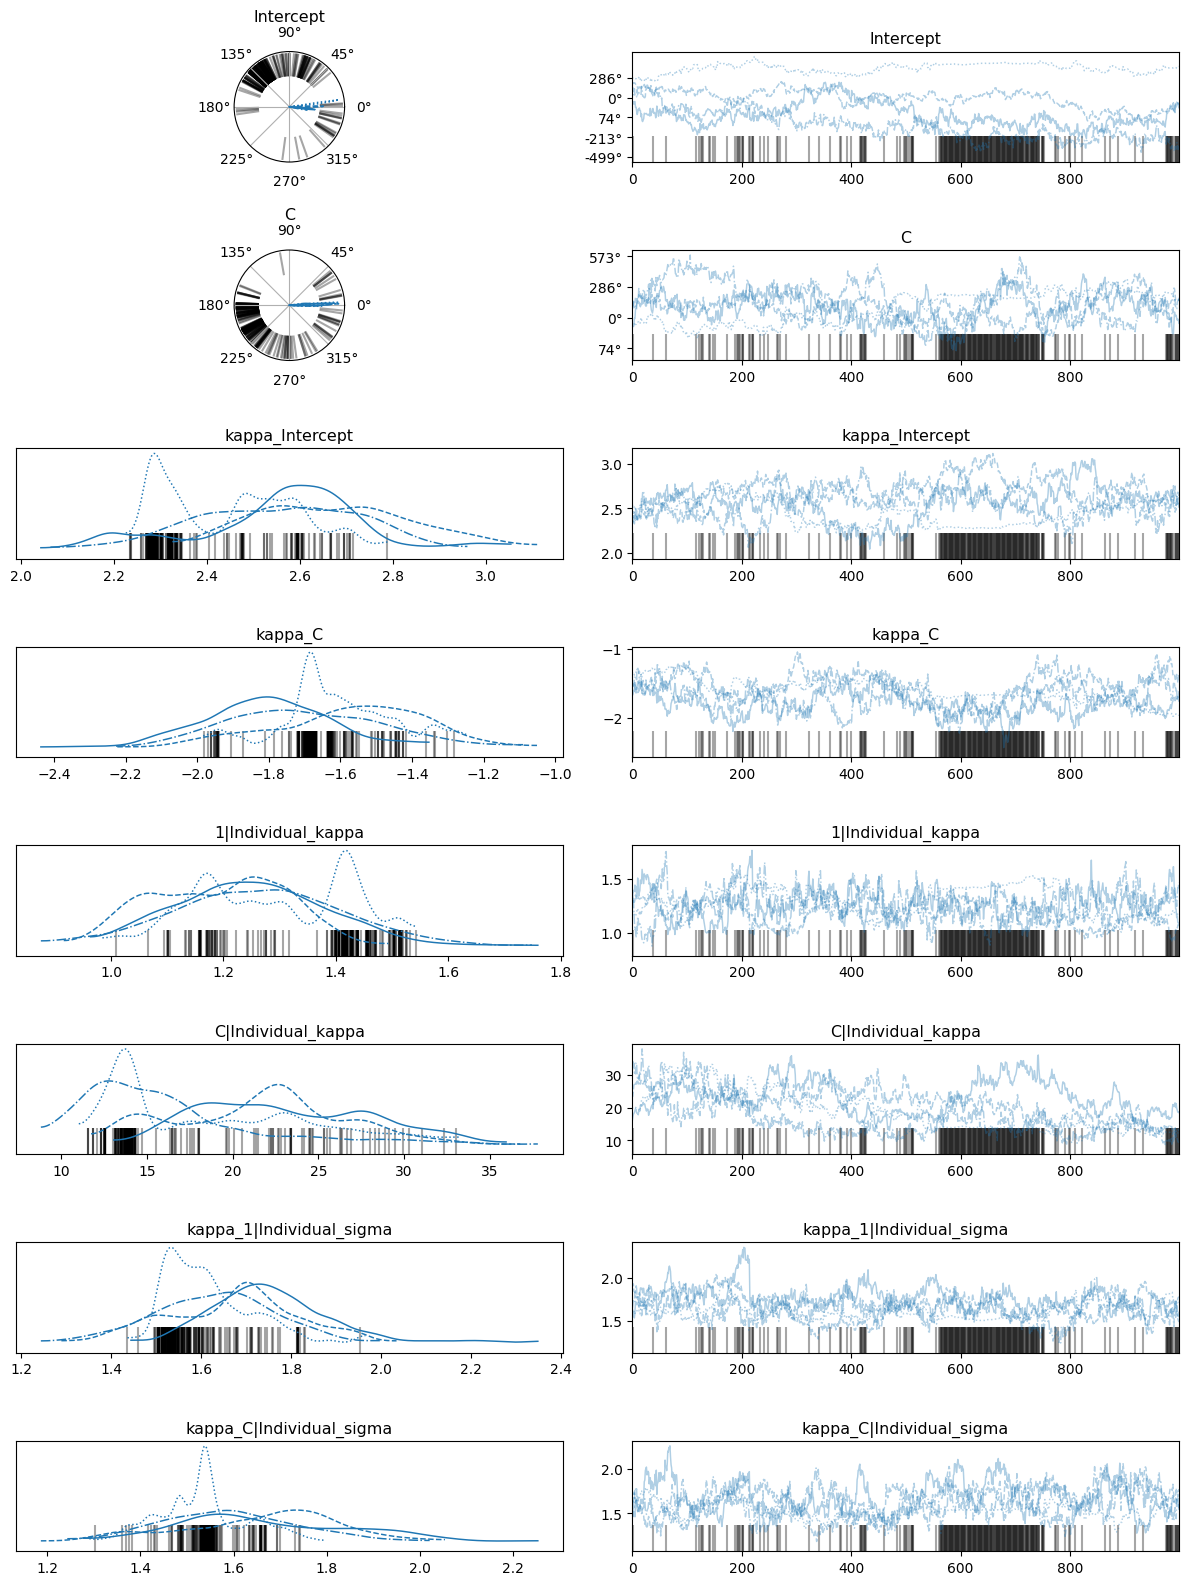

In [ ]:
plot_circular_trace(
                    idata = idata_additive_interactionKappa,
                    vars=[
                            "Intercept",
                            "C",
                            "B",
                            "kappa_Intercept",
                            "kappa_C",
                            "kappa_B",
                            "kappa_B:C",
                            "1|Individual_kappa",
                            "C|Individual_kappa",
                            "B|Individual_kappa",
                            "kappa_1|Individual_sigma",
                            "kappa_C|Individual_sigma",
                            "kappa_B|Individual_sigma",
                            "kappa_B:C|Individual_sigma",
                        ],
                    cvars = ["Intercept",
                            "C",
                            "B",
                            ]
)

# Model comparison for hypothesis testing
These models represent different hypotheses about the underlying causes of the data. 
We can test these hypotheses by comparing predictive power.


In [ ]:
# Calculate predictive power using LOO cross-validation
import pymc as pm
import arviz as az

loo_UV = az.loo(idata_UV)
loo_dim = az.loo(idata_dim)
loo_UV_dimKappa = az.loo(idata_UV_dimKappa)
loo_dim_UVKappa = az.loo(idata_dim_UVKappa)
loo_additive = az.loo(idata_additive)
loo_additive_interactionKappa = az.loo(idata_additive_interactionKappa)
loo_interaction = az.loo(idata_idata)

In [ ]:

# Print the results
print('\n----- Model 1: UV (C only) -----\n')
print(loo_UV)

print('\n----- Model 2: Dim (B only) -----\n')
print(loo_dim)

print('\n----- Model 3: UV angle, Dim+UV kappa -----\n')
print(loo_UV_dimKappa)

print('\n----- Model 4: Dim angle, Dim+UV kappa -----\n')
print(loo_dim_UVKappa)

print('\n----- Model 5: Additive (B + C) -----\n')
print(loo_additive)

print('\n----- Model 6: Kappa interaction (B * C) -----\n')
print(loo_additive_interactionKappa)

print('\n----- Model 7: Full interaction (B * C) -----\n')
print(loo_interaction)

In [ ]:
# Compare, ranking models from best to worst
comparison = az.compare({
    'UV (C)': loo_UV,
    'Dim (B)': loo_dim,
    'UV_dimKappa': loo_UV_dimKappa,
    'Dim_UVKappa': loo_dim_UVKappa,
    'Additive': loo_additive,
    'Interaction': loo_interaction
}, ic="loo")

print('\n----- Model Comparison Ranking -----\n')
print(comparison)

# Visualize the comparison
az.plot_compare(comparison)

## Plot model comparison
Plot relative and contrasted ELPD for the models of interest.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import matplotlib.pyplot as plt
import arviz as az


# 2. Set up the dual-panel canvas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharex=False)
fig.subplots_adjust(wspace=0.3)

# Assign a custom color map matching your preferences
models = comparison.index.tolist()
colors = ["#A020F0", "#404040","#008B00", "#CD00CD","#666666","#00CD00"] 
color_map = {model: colors[i % len(colors)] for i, model in enumerate(models)}

# =========================================================================
# PANEL 1: Absolute ELPD Estimates (Ranked Best to Worst)
# =========================================================================
for i, model in enumerate(models):
    elpd = comparison.loc[model, "elpd_loo"]
    se = comparison.loc[model, "se"]
    color = color_map[model]
    
    # Plot point estimate and 1-sigma / 2-sigma error bounds
    ax1.errorbar(x=i, y=elpd, yerr=se, fmt='o', color=color, elinewidth=3, markersize=9, label=model)
    ax1.errorbar(x=i, y=elpd, yerr=2*se, fmt='none', color=color, elinewidth=1, alpha=0.6)

# Visual anchors for Panel 1
ax1.axhline(comp_df.iloc[0]["elpd_loo"], color="gray", linestyle="--", alpha=0.7)
ax1.set_title("Absolute Model Performance", fontsize=12, fontweight='bold')
ax1.set_ylabel("Expected Log Predictive Density (ELPD)", fontsize=11)
ax1.set_xticks(range(len(models)))
ax1.set_xticklabels([m.replace(" ", "\n") for m in models], fontsize=10)
ax1.set_xlim(-0.5, len(models) - 0.5)

# =========================================================================
# PANEL 2: Relative ELPD Differences (From Best)
# =========================================================================
for i, model in enumerate(models):
    elpd_diff = comparison.loc[model, "elpd_diff"]
    se_diff = comparison.loc[model, "dse"]
    color = color_map[model]
    
    if i == 0:
        # Best model serves as the baseline comparison point (diff=0, se=0)
        ax2.plot(i, -elpd_diff, 'o', fillstyle='none', color=color, markersize=9, markeredgewidth=2)
    else:
        # ArviZ records elpd_diff as positive values tracking distance *down* from best. 
        # We invert it (-elpd_diff) to match your R plot's downward drop.
        ax2.errorbar(x=i, y=-elpd_diff, yerr=se_diff, fmt='o', color=color, elinewidth=3, markersize=9)
        ax2.errorbar(x=i, y=-elpd_diff, yerr=2*se_diff, fmt='none', color=color, elinewidth=1, alpha=0.6)

# Visual anchors for Panel 2
ax2.axhline(0, color="black", linestyle=":", alpha=0.8)
ax2.set_title("Pairwise Divergence Metrics", fontsize=12, fontweight='bold')
ax2.set_ylabel(r"$\Delta$ ELPD (Relative to Best)", fontsize=11)
ax2.set_xticks(range(len(models)))
ax2.set_xticklabels([m.replace(" ", "\n") for m in models], fontsize=10)
ax2.set_xlim(-0.5, len(models) - 0.5)

plt.show()

# Extract & inspect posterior samples from maximal model

/var/folders/nq/smdrxv810_z_tfcmgmg5gkb00000gn/T/ipykernel_2430/2346096510.py:120: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  individual_circmean_gl  = shifted_modulo(circmean(headings_gl))
/var/folders/nq/smdrxv810_z_tfcmgmg5gkb00000gn/T/ipykernel_2430/2346096510.py:119: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  individual_circmean_gh = shifted_modulo(circmean(headings_gh))
/var/folders/nq/smdrxv810_z_tfcmgmg5gkb00000gn/T/ipykernel_2430/2346096510.py:121: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  individual_circmean_uh = shifted_modulo(circmean(headings_uh))
/var/folders/nq/smdrxv810_z_tfcmgmg5gkb00000gn/T/ipykernel_2430/2346096510.py:122: SmallSampleWarning: One or more sample a

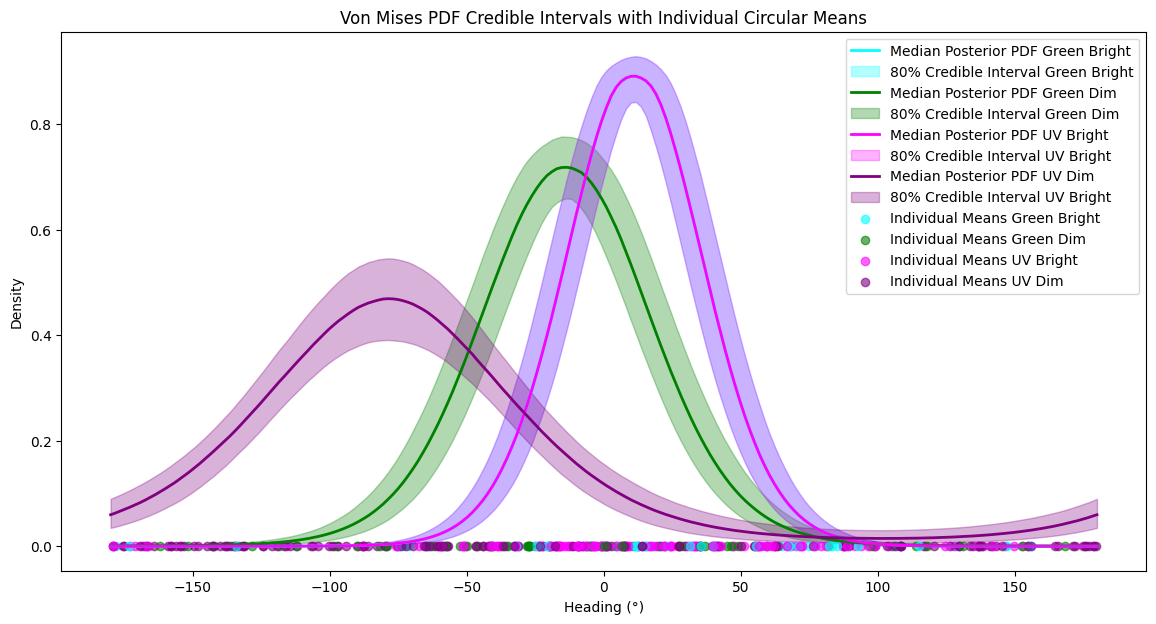

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import vonmises, circmean

# Import shifted_modulo and softplus from unwrap.link.numpy
from unwrap.link.numpy import shifted_modulo, softplus

# --------------------------------------------------
# Extract posterior samples for population-level parameters
# using the Bambi naming scheme with capitalized variable names.
# --------------------------------------------------
# For the μ-model (the main target):
mu_intercept = idata.posterior['Intercept'].values          # fixed intercept for μ
mu_slopeB    = idata.posterior['B'].values               # fixed slope for μ # Not working?
mu_slopeC    = idata.posterior['C'].values               # fixed slope for μ # Not the right name?
mu_slopeBC   = idata.posterior['B:C'].values               # fixed slope for μ

# For the κ-model:
kappa_intercept = idata.posterior['kappa_Intercept'].values    # fixed intercept for κ (linear predictor)
kappa_slopeB    = idata.posterior['kappa_B'].values        # fixed slope for κ (linear predictor)
kappa_slopeC    = idata.posterior['kappa_C'].values        # fixed slope for κ (linear predictor)
kappa_slopeBC   = idata.posterior['kappa_B:C'].values        # fixed slope for κ (linear predictor)

# --------------------------------------------------
# Prepare a grid for plotting the von Mises PDFs
# --------------------------------------------------
theta = np.linspace(-np.pi, np.pi, 200)
theta_deg = theta.copy()*180/np.pi

fig, ax = plt.subplots(figsize=(14, 7))

# Total number of posterior samples available.
num_samples = mu_intercept.flatten().shape[0]

# Compute population-level parameters for each condition.
mu_pop_gh_samples_all = shifted_modulo(mu_intercept.flatten())
mu_pop_gl_samples_all  = shifted_modulo((mu_intercept + mu_slopeB).flatten())
mu_pop_uh_samples_all  = shifted_modulo((mu_intercept + mu_slopeC).flatten())
mu_pop_ul_samples_all  = shifted_modulo((mu_intercept + mu_slopeB + mu_slopeC + mu_slopeBC).flatten())
kappa_pop_gh_samples_all = softplus(kappa_intercept.flatten())
kappa_pop_gl_samples_all  = softplus((kappa_intercept + kappa_slopeB).flatten())
kappa_pop_uh_samples_all  = softplus((kappa_intercept + kappa_slopeC).flatten())
kappa_pop_ul_samples_all  = softplus((kappa_intercept + kappa_slopeB + kappa_slopeC + kappa_slopeBC).flatten())

# --------------------------------------------------
# Compute the von Mises PDF for each posterior sample at each theta.
# The resulting arrays have shape (num_samples, len(theta)).
# --------------------------------------------------
pdf_gh = vonmises.pdf(
    theta[None, :],
    kappa=kappa_pop_gh_samples_all[:, None],
    loc=mu_pop_gh_samples_all[:, None]
)
pdf_gl = vonmises.pdf(
    theta[None, :],
    kappa=kappa_pop_gl_samples_all[:, None],
    loc=mu_pop_gl_samples_all[:, None]
)
pdf_uh = vonmises.pdf(
    theta[None, :],
    kappa=kappa_pop_uh_samples_all[:, None],
    loc=mu_pop_uh_samples_all[:, None]
)
pdf_ul = vonmises.pdf(
    theta[None, :],
    kappa=kappa_pop_ul_samples_all[:, None],
    loc=mu_pop_ul_samples_all[:, None]
)

# For each theta, compute the median and the 95% credible interval. #JJF this appears to be the 80%CI!
median_pdf_gh = np.median(pdf_gh, axis=0)
lower_pdf_gh  = np.percentile(pdf_gh, 10, axis=0)
upper_pdf_gh  = np.percentile(pdf_gh, 90, axis=0)

median_pdf_gl = np.median(pdf_gl, axis=0)
lower_pdf_gl  = np.percentile(pdf_gl, 10, axis=0)
upper_pdf_gl  = np.percentile(pdf_gl, 90, axis=0)

median_pdf_uh = np.median(pdf_gh, axis=0)
lower_pdf_uh  = np.percentile(pdf_gh, 10, axis=0)
upper_pdf_uh  = np.percentile(pdf_gh, 90, axis=0)

median_pdf_ul = np.median(pdf_ul, axis=0)
lower_pdf_ul  = np.percentile(pdf_ul, 10, axis=0)
upper_pdf_ul  = np.percentile(pdf_ul, 90, axis=0)

# --------------------------------------------------
# Plot the median PDFs and fill between the 95% credible intervals.
# --------------------------------------------------
ax.plot(theta_deg, median_pdf_gh, color='cyan', lw=2, label='Median Posterior PDF Green Bright')
ax.fill_between(theta_deg, lower_pdf_gh, upper_pdf_gh, color='cyan', alpha=0.3,
                label='80% Credible Interval Green Bright')

ax.plot(theta_deg, median_pdf_gl, color='green', lw=2, label='Median Posterior PDF Green Dim')
ax.fill_between(theta_deg, lower_pdf_gl, upper_pdf_gl, color='green', alpha=0.3,
                label='80% Credible Interval Green Dim')

ax.plot(theta_deg, median_pdf_uh, color='magenta', lw=2, label='Median Posterior PDF UV Bright')
ax.fill_between(theta_deg, lower_pdf_uh, upper_pdf_uh, color='magenta', alpha=0.3,
                label='80% Credible Interval UV Bright')

ax.plot(theta_deg, median_pdf_ul, color='purple', lw=2, label='Median Posterior PDF UV Dim')
ax.fill_between(theta_deg, lower_pdf_ul, upper_pdf_ul, color='purple', alpha=0.3,
                label='80% Credible Interval UV Bright')

# --------------------------------------------------
# Plot the circular means for each individual (individual-level summaries)
# --------------------------------------------------
for i, individual in enumerate(df['Individual'].unique()):
    individual_data = df[df['Individual'] == individual]
    
    # Get headings for Light Off (Light == 0) and Light On (Light == 1)
    headings_gh = individual_data.loc[(individual_data['B'] == 0) & (individual_data['C'] == 0), 'angle'].dropna()
    headings_gl = individual_data.loc[(individual_data['B'] == 1) & (individual_data['C'] == 0), 'angle'].dropna()
    headings_uh = individual_data.loc[(individual_data['B'] == 0) & (individual_data['C'] == 1), 'angle'].dropna()
    headings_ul = individual_data.loc[(individual_data['B'] == 1) & (individual_data['C'] == 1), 'angle'].dropna()
    
    # Compute circular means for this individual and wrap into [-π, π] using shifted_modulo.
    individual_circmean_gh = shifted_modulo(circmean(headings_gh))
    individual_circmean_gl  = shifted_modulo(circmean(headings_gl))
    individual_circmean_uh = shifted_modulo(circmean(headings_uh))
    individual_circmean_ul  = shifted_modulo(circmean(headings_ul))
    
    # Plot individual circular means.
    ax.scatter(individual_circmean_gh*180/np.pi, 0, color='cyan', alpha=0.6,
               label='Individual Means Green Bright' if i == 0 else "")
    ax.scatter(individual_circmean_gl*180/np.pi, 0, color='green', alpha=0.6,
               label='Individual Means Green Dim' if i == 0 else "")
    ax.scatter(individual_circmean_uh*180/np.pi, 0, color='magenta', alpha=0.6,
               label='Individual Means UV Bright' if i == 0 else "")
    ax.scatter(individual_circmean_ul*180/np.pi, 0, color='purple', alpha=0.6,
               label='Individual Means UV Dim' if i == 0 else "")

ax.set_title('Von Mises PDF Credible Intervals with Individual Circular Means')
ax.set_xlabel('Heading (°)')
ax.set_ylabel('Density')
ax.legend()
plt.show()